# B1 – Axis 2 (supply side): where does DNSE still have room and efficiency to grow?

**Author:** Phong (Team B) · **Input:** `data/raw/FBAR2_TEAM B DATASET.xlsx` (collected by the team's BA, version 25/09/2026)

**What this notebook does:**
1. **Extract** only the *hard-typed* input cells (not formulas) from the Excel file into tidy tables in `data/clean/`.
2. **Clean** the data and log every issue (codes D01–D24; see `report/data_issues_log.md`).
3. **Validate** by re-computing every Excel formula in pandas and comparing with the values Excel stored.
4. **Compute axis-2 metrics** under the agreed definitions:
   - 2.1 momentum
   - 2.2 headroom
   - 2.3 efficiency
5. **Plot** Figures 8–11.
6. **Score** Table 4 (2.1–2.4, with 2.5 merged into 2.4) and run the sensitivity check (Table PL2).
7. **Generate** a short method-and-findings summary and the source register.

**Conventions:**
- Money in **VND billion**.
- Ratios stored as decimals (0.25 = 25%).
- Share changes in **percentage points (pp)**.
- Run with *Restart & Run all*.

## 0. Setup

In [1]:
import warnings, re, datetime as dt
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import openpyxl
import matplotlib.pyplot as plt

ROOT  = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
RAW   = ROOT / "data/raw/FBAR2_TEAM_B_DATASET_v2.xlsx"
CLEAN = ROOT / "data/clean"
FIG   = ROOT / "figures"
CLEAN.mkdir(parents=True, exist_ok=True)
(ROOT / "report").mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

TICKERS = ["DSE", "SSI", "VND", "HCM", "VCI", "MBS"]
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

wb_f = openpyxl.load_workbook(RAW)
wb_v = openpyxl.load_workbook(RAW, data_only=True)

def v(sheet, addr):
    return wb_v[sheet][addr].value

def f(sheet, addr):
    x = wb_f[sheet][addr].value
    return getattr(x, "text", x)

print("Sheets:", wb_v.sheetnames)

Sheets: ['2.1_NewInvestors', '2.1_Margin', '2.1_Derivatives', '2.1_Summary', '2.2_NewInvestors', '2.2_Margin', '2.2_Derivatives', '2.3_Brokerage', '2.3_Margin', '2.3_Derivatives', '2.5_Pricing', '2.5.1_EquityShareStructure', '2.5_MarginShareStructure', '2.5.3_DerivShareStructure']


## 1. Extract hard-typed inputs

Only cells the BA typed in directly are read. Every formula cell is **re-computed** in section 3 as a check, never copied.

The cleaning log starts here; every fix appends one row.

In [2]:
LOG = []
def log(code, sheet, cell, issue, action, before=None, after=None):
    LOG.append(dict(code=code, sheet=sheet, cell=cell, issue=issue,
                    action=action, before=before, after=after))

S = "2.1_NewInvestors"
acq_raw = pd.DataFrame([{
    "row": r,
    "period_label":      v(S, f"A{r}"),
    "report_date_raw":   v(S, f"B{r}"),
    "new_account_share": v(S, f"C{r}"),
    "source_report":     v(S, f"E{r}"),
} for r in range(2, 6)])

base_raw = pd.DataFrame([{
    "row": r,
    "ref_date_raw":  v(S, f"H{r}"),
    "accounts":      v(S, f"I{r}"),
    "qualifier":     v(S, f"J{r}"),
    "source_id_raw": v(S, f"L{r}"),
} for r in range(2, 6)])

S = "2.1_Margin"
mh = pd.DataFrame([{
    "row": r,
    "quarter":   v(S, f"A{r}"),
    "ticker":    v(S, f"B{r}"),
    "margin_bn": v(S, f"C{r}"),
    "source_id": v(S, f"F{r}"),
} for r in range(2, 26)])

S = "2.1_Derivatives"
ds = pd.DataFrame([{
    "row": r,
    "quarter":   v(S, f"A{r}"),
    "rank":      v(S, f"B{r}"),
    "broker":    v(S, f"C{r}"),
    "share":     v(S, f"D{r}"),
    "source_id": v(S, f"E{r}"),
} for r in range(2, 72)])

S = "2.2_Margin"
bs = pd.DataFrame([{
    "ticker":          v(S, f"A{r}"),
    "equity_q4_25":    v(S, f"C{r}"),
    "equity_q2_26":    v(S, f"E{r}"),
    "debt_q4_25":      v(S, f"Q{r}"),
    "debt_q2_26":      v(S, f"R{r}"),
    "cash_q2_26":      v(S, f"S{r}"),
    "int_exp_h1_26":   v(S, f"T{r}"),
    "bank_affiliated": v(S, f"Z{r}") == "Yes",
} for r in range(2, 8)])

S = "2.3_Margin"
lend = pd.DataFrame([{
    "ticker":               v(S, f"A{r}"),
    "lending_q4_25":        v(S, f"E{r}"),
    "lending_q2_26":        v(S, f"H{r}"),
    "lending_income_h1_26": v(S, f"J{r}"),
    "other_borrow_cost_h1_26": v(S, f"O{r}"),
    "other_borrow_cost_formula": str(f(S, f"O{r}")),
} for r in range(2, 8)])

S = "2.3_Brokerage"
brk = pd.DataFrame([{
    "ticker":         v(S, f"A{r}"),
    "brk_rev_h1_25":  v(S, f"B{r}"),
    "brk_exp_h1_25":  v(S, f"C{r}"),
    "brk_rev_h1_26":  v(S, f"F{r}"),
    "brk_exp_h1_26":  v(S, f"G{r}"),
} for r in range(2, 8)])

S = "2.2_NewInvestors"
newinv = {v(S, f"A{r}"): v(S, f"B{r}") for r in range(2, 8)}

S = "2.2_Derivatives"
deriv_mkt = {v(S, f"A{r}"): v(S, f"B{r}") for r in range(10, 13)}

S = "2.3_Derivatives"
fee_raw = pd.DataFrame([{
    "row": r,
    "contracts_from": v(S, f"A{r}"),
    "contracts_to":   v(S, f"B{r}"),
    "fee_raw":        v(S, f"C{r}"),
} for r in range(2, 7)])
deriv_param = {
    "matched_contracts_h1_26": v(S, "G2"),
    "dse_share_h1_26":         v(S, "G3"),
    "side_factor":             v(S, "G4"),
    "annualisation":           v(S, "G5"),
}

print("Extracted:",
      f"{len(mh)} margin rows, {len(ds)} derivatives rows, {len(bs)} brokers' financials")

Extracted: 24 margin rows, 70 derivatives rows, 6 brokers' financials


## 2. Clean and log

Issue codes match `report/data_issues_log.md`.

In [3]:
def parse_date(x, sheet, cell):
    if isinstance(x, dt.datetime):
        fixed = pd.Timestamp(year=x.year, month=x.day, day=x.month)
        log("D04", sheet, cell, "Date parsed month-first, breaking chronological order",
            "Swap day and month back", x.date().isoformat(), fixed.date().isoformat())
        return fixed
    return pd.to_datetime(x, dayfirst=True)

acq = acq_raw.copy()
acq["report_date"] = [parse_date(x, "2.1_NewInvestors", f"B{r}")
                      for x, r in zip(acq.report_date_raw, acq.row)]
base = base_raw.copy()
base["ref_date"] = [parse_date(x, "2.1_NewInvestors", f"H{r}")
                    for x, r in zip(base.ref_date_raw, base.row)]
log("D05", "2.1_NewInvestors", "B2:B5,H2:H5", "Dates stored as text",
    "Parse with dayfirst=True", "text", "datetime")

acq["period_covered"] = acq.period_label.replace({"FY/2025": "FY2025"})
log("D06", "2.1_NewInvestors", "A5/E5", "Label says FY/2025 but period column says Q4/2025",
    "Treated as full-year 2025 (matches the Masterplan); column E renamed source_report",
    "Q4/2025", "FY2025")

ID_RE = re.compile(r"^[A-Z]+\d+(\.\d+)?$")
base["source_id"] = base.source_id_raw.where(base.source_id_raw.astype(str).str.match(ID_RE))
for r, raw in zip(base.row, base.source_id_raw):
    if not ID_RE.match(str(raw)):
        log("D07", "2.1_NewInvestors", f"L{r}", "Source_ID holds a reporting period",
            "Source ID left blank, pending BA", raw, None)

base["is_lower_bound"] = base.qualifier.eq(">")
base["is_approx"]      = base.qualifier.eq("~")
base = base.sort_values("ref_date").reset_index(drop=True)

mh["source_id"] = mh.groupby("quarter")["source_id"].ffill()
ds["source_id"] = ds.groupby("quarter")["source_id"].ffill()
ds["rank"] = ds["rank"].astype(int)

fee = fee_raw.copy()
fee["negotiable"] = fee.fee_raw.astype(str).str.contains("agreement")
fee["fee_vnd"] = fee.fee_raw.astype(str).str.extract(r"(\d+)")[0].astype(float)
fee["contracts_to"] = pd.to_numeric(fee.contracts_to, errors="coerce")
for r, raw in zip(fee.row, fee.fee_raw):
    if isinstance(raw, str):
        log("D11", "2.3_Derivatives", f"C{r}", "Text in a numeric column",
            "Use 300 and flag negotiable", raw.strip(), 300)
log("D12", "2.3_Derivatives", "F4", "Truncated label '[Asss'",
    "Renamed to side_factor [ASSUMPTION] = 2", v("2.3_Derivatives", "F4"), "side_factor [ASSUMPTION]")

m_q4 = mh[mh.quarter == "Q4/2025"].set_index("ticker").margin_bn
m_q2 = mh[mh.quarter == "Q2/2026"].set_index("ticker").margin_bn
adv = lend.set_index("ticker")[["lending_q4_25", "lending_q2_26"]].copy()
adv["advances_q4_25"] = adv.lending_q4_25 - m_q4
adv["advances_q2_26"] = adv.lending_q2_26 - m_q2
adv["margin_fig_is_total_lending_q4"] = adv.advances_q4_25.abs() < 1
adv["margin_fig_is_total_lending_q2"] = adv.advances_q2_26.abs() < 1
for t, row in adv.iterrows():
    flags = [q for q, fl in [("Q4/2025", row.margin_fig_is_total_lending_q4),
                             ("Q2/2026", row.margin_fig_is_total_lending_q2)] if fl]
    if flags:
        log("D01", "2.1_Margin / 2.3_Margin", t,
            f"'Margin' figure {', '.join(flags)} equals total loans in 2.3_Margin, i.e. already includes advances"
            + (" (DSE: advances 584 bn at end-2025, 178 bn at 30/6/2026)" if t == "DSE" else ""),
            "Use total loans (code 114) for all six brokers")
display(adv.round(2))

lend_xl = lend.copy()
LINE24_DSE_6M26     = 248_925_871_777 / 1e9
PROV_LOANS_DSE_6M26 = 8_964_451_724 / 1e9
DSE_BORROW_COST_LOANS_6M26 = LINE24_DSE_6M26 - PROV_LOANS_DSE_6M26
old = lend.loc[lend.ticker == "DSE", "other_borrow_cost_h1_26"].iloc[0]
lend.loc[lend.ticker == "DSE", "other_borrow_cost_h1_26"] = DSE_BORROW_COST_LOANS_6M26
log("D02", "2.3_Margin", "O2 (DSE)",
    "Hard-coded 240 bn borrowing cost; BA located the source (6M/2026 FS, code 24, note 29)",
    "Use exact value = 248.926 - 8.964 bn", round(old, 3), round(DSE_BORROW_COST_LOANS_6M26, 3))

log("D02b", "2.3_Margin", "O3:O7",
    "Peers may also book borrowing costs in code 24 but are set to 0",
    "CLOSED: peers' code 24 checked in their statements (SSI, VND, VCI, MBS ≈ 0; HCM already in interest expense) → keep 0 (see D16)")

HCM_BORROW_FY2025 = 1_452_771_109_720 / 1e9
log("D16", "2.3_Margin", "T5/O5 (HCM)",
    "HCM books ALL borrowing costs in code 24 (FY2025 VND 1,452.77 bn; no separate interest-expense line)",
    "Checked: the 1,031.6 bn the BA recorded as H1/2026 interest expense IS code 24 -> kept; O5 = 0 is correct (avoids double counting)")

tl = mh[mh.quarter.isin(["Q4/2024", "Q2/2025"])][["ticker", "quarter", "margin_bn"]].rename(columns={"margin_bn": "total_loans_bn"})
tl["source"] = "BA 2.1_Margin (verified = FS code 114)"
tl.loc[(tl.ticker == "DSE") & (tl.quarter == "Q4/2024"), ["total_loans_bn", "source"]] = [3_881_585_476_070 / 1e9, "DNSE Annual Report 2025, note 7(c)"]
tl.loc[(tl.ticker == "DSE") & (tl.quarter == "Q2/2025"), ["total_loans_bn", "source"]] = [5_052_616_668_312 / 1e9, "DNSE FS Q2/2025, code 114"]
tl.loc[(tl.ticker == "VCI") & (tl.quarter == "Q2/2025"), ["total_loans_bn", "source"]] = [11_306_616_014_808 / 1e9, "VCI FS Q2/2025, code 114"]
for q, col in [("Q4/2025", "lending_q4_25"), ("Q2/2026", "lending_q2_26")]:
    t = lend[["ticker", col]].rename(columns={col: "total_loans_bn"}); t["quarter"] = q
    t["source"] = "BA 2.3_Margin E/H (verified = FS code 114)"
    tl = pd.concat([tl, t], ignore_index=True)
tl["sample_total"] = tl.groupby("quarter").total_loans_bn.transform("sum")
tl["share"] = tl.total_loans_bn / tl.sample_total
tl.to_csv(CLEAN / "B_total_loans_consistent.csv", index=False)
log("D17", "2.1_Margin", "C2 (DSE Q4/2024)", "DSE Q4/2024 (3,785) is margin-only while later dates are total loans",
    "Replaced by total loans 3,881.59 bn (DNSE Annual Report 2025, note 7c)", 3785, 3881.59)
log("D18", "2.1_Margin", "C15,C16,C19 (Q4/2025)", "SSI, VND, MBS Q4/2025 in 2.1_Margin are margin-only",
    "Use total loans, code 114 (= 2.3_Margin E, verified against the statements)", "38,616 / 13,647 / 14,517", "38,940 / 14,319 / 15,041")
log("D19", "2.1_Margin", "C8, C12 (Q2/2025)", "DSE Q2/2025 (4,835) is margin-only; VCI Q2/2025 not yet verified",
    "Checked against Q2/2025 statements: DSE total loans 5,052.62 bn (fixed); VCI 11,306.62 bn (matches BA)", 4835, 5052.62)

q4 = pd.read_csv(ROOT / "data/sources/bctc_quarterly_4Q_official.csv", encoding="utf-8-sig")
QTRS = ["Q3/2025", "Q4/2025", "Q1/2026", "Q2/2026"]
bq = q4.pivot_table(index=["ticker", "quarter"], columns="variable", values="value_bn").reset_index()
chk_tl = tl[tl.quarter.isin(["Q4/2025", "Q2/2026"])].merge(bq, on=["ticker", "quarter"])
assert np.allclose(chk_tl.total_loans_bn_x, chk_tl.total_loans_bn_y, atol=0.2), "code 114 differs from the dataset"
h1 = bq[bq.quarter.isin(["Q1/2026", "Q2/2026"])].groupby("ticker")[["rev_brokerage_bn", "int_loans_receivables_bn"]].sum()
recon_h1 = h1.join(brk.set_index("ticker").brk_rev_h1_26).join(lend.set_index("ticker").lending_income_h1_26)
recon_h1["diff_brk"] = recon_h1.rev_brokerage_bn - recon_h1.brk_rev_h1_26
recon_h1["diff_lend"] = recon_h1.int_loans_receivables_bn - recon_h1.lending_income_h1_26
display(recon_h1.round(2))
log("D23", "(new)", "24 statements", "Leader needs quarterly Q3/2025-Q2/2026 figures (codes 06, 03, 114)",
    "Read from statements; Q1+Q2/2026 match the BA H1 figures (max gap %.2f bn)" % recon_h1[["diff_brk", "diff_lend"]].abs().max().max())

tl4 = bq[["ticker", "quarter", "total_loans_bn"]].copy()
tl4["sample_total"] = tl4.groupby("quarter").total_loans_bn.transform("sum")
tl4["share"] = tl4.total_loans_bn / tl4.sample_total
dse_loan_share_q = tl4[tl4.ticker == "DSE"].set_index("quarter").share.reindex(QTRS)
log("D20", "2.1_NewInvestors", "C2:C5", "New-account shares came from press and mixed period types",
    "Use DNSE annual-report figures: FY2024 21.6%; Q1-Q4/2025 = 34/18/16/19%; FY2025 20%")
acq_off = pd.DataFrame({"period": ["FY2024", "Q4/2024", "Q1/2025", "Q2/2025", "Q3/2025", "Q4/2025", "FY2025", "Q1/2026"],
                        "share": [0.216, 99509/432000, 131122/388089, 104785/583849, 127344/773999, 155263/828008, 518514/2573945, 0.18],
                        "source": ["DNSE Annual Report 2024", "DNSE Annual Report 2024 / VSDC via press ('more than 432,000') – upper bound"]
                                  + ["DNSE Annual Report 2025, Figure 21"] * 5 + ["Vietstock 18/04/2026 (142,000 accounts, 18%)"]})
acq_off.to_csv(CLEAN / "B_new_account_share_official.csv", index=False)
display(tl.pivot(index="ticker", columns="quarter", values="total_loans_bn").round(1))

,lending_q4_25,lending_q2_26,advances_q4_25,advances_q2_26,margin_fig_is_total_lending_q4,margin_fig_is_total_lending_q2
ticker,,,,,,
DSE,5832.2,6303.10,0.2,0.10,True,True
SSI,38940.1,40472.60,324.1,436.02,False,False
VND,14319.0,12859.04,672.0,196.04,False,False
HCM,28150.1,29023.50,0.1,-0.02,True,True
VCI,16167.2,17145.80,0.2,499.34,True,False
MBS,15040.6,16828.10,523.6,157.70,False,False


,rev_brokerage_bn,int_loans_receivables_bn,brk_rev_h1_26,lending_income_h1_26,diff_brk,diff_lend
ticker,,,,,,
DSE,222.05,336.08,222.1,336.10,-0.05,-0.02
HCM,520.97,1531.24,521.0,1531.30,-0.03,-0.06
MBS,404.95,904.78,404.9,904.70,0.05,0.07
SSI,1068.45,2141.43,1069.0,2141.40,-0.55,0.03
VCI,565.53,877.56,565.6,877.50,-0.07,0.06
VND,381.65,777.97,381.6,777.98,0.05,-0.01


quarter,Q2/2025,Q2/2026,Q4/2024,Q4/2025
ticker,,,,
DSE,5052.6,6303.1,3881.6,5832.2
HCM,19813.0,29023.5,20429.0,28150.1
MBS,12796.0,16828.1,10294.0,15040.6
SSI,33134.0,40472.6,21999.0,38940.1
VCI,11306.6,17145.8,11222.0,16167.2
VND,10644.0,12859.0,10344.0,14319.0


### 2.1 Save clean tables

In [4]:
tables = {
    "B_acquisition_share.csv": acq[["period_label", "period_covered", "report_date",
                                    "new_account_share", "source_report"]],
    "B_account_base.csv":      base[["ref_date", "accounts", "qualifier", "is_lower_bound",
                                     "is_approx", "source_id"]],
    "B_margin_reported_quarterly.csv": mh.drop(columns="row"),
    "B_derivatives_share_quarterly.csv": ds.drop(columns="row"),
    "B_balance_sheet.csv": bs,
    "B_lending.csv":       lend.drop(columns="other_borrow_cost_formula"),
    "B_brokerage.csv":     brk,
    "B_deriv_fee_schedule.csv": fee.drop(columns=["row", "fee_raw"]),
}
for name, df in tables.items():
    df.to_csv(CLEAN / name, index=False)
pd.Series(newinv, name="value").to_csv(CLEAN / "B_newinv_inputs.csv")
pd.Series({**deriv_mkt, **deriv_param}, name="value").to_csv(CLEAN / "B_deriv_inputs.csv")
print("Saved", len(tables) + 2, "files to", CLEAN)

Saved 10 files to /sessions/rcw-01j9p5bjh2qf52enqwypiwpk/mnt/FBA/Submission/data/clean


## 3. Validation: re-compute the Excel formulas

Metrics are re-computed **exactly as the BA's formulas do**, including definitions that section 4 later replaces, and compared with the stored Excel values.
- A match (tolerance ≤ 1e-6) means extraction is correct and the spreadsheet has no broken references.
- Any mismatch must be investigated.

In [5]:
checks = []
def check(name, sheet, cell, ours):
    xl = v(sheet, cell)
    ok = xl is not None and np.isclose(float(ours), float(xl), rtol=1e-6, atol=1e-6)
    checks.append(dict(metric=name, sheet=sheet, cell=cell, excel=xl, python=float(ours), match=ok))

mh["sample_total"] = mh.groupby("quarter").margin_bn.transform("sum")
for _, r in mh.iterrows():
    check(f"margin share {r.ticker} {r.quarter}", "2.1_Margin", f"E{r.row}", r.margin_bn / r.sample_total)

b = bs.set_index("ticker")
for i, t in enumerate(TICKERS, start=2):
    cap = 2 * b.at[t, "equity_q2_26"]
    check(f"utilisation {t}", "2.2_Margin", f"G{i}", m_q2[t] / cap)
    check(f"headroom {t}",    "2.2_Margin", f"H{i}", cap - m_q2[t])
    avg_debt = (b.at[t, "debt_q4_25"] + b.at[t, "debt_q2_26"]) / 2
    check(f"funding cost (interest only) {t}", "2.2_Margin", f"V{i}", b.at[t, "int_exp_h1_26"] * 2 / avg_debt)

L = lend_xl.set_index("ticker")
for i, t in enumerate(TICKERS, start=2):
    avg_lend = (L.at[t, "lending_q4_25"] + L.at[t, "lending_q2_26"]) / 2
    y = L.at[t, "lending_income_h1_26"] * 2 / avg_lend
    avg_debt = (b.at[t, "debt_q4_25"] + b.at[t, "debt_q2_26"]) / 2
    c = (b.at[t, "int_exp_h1_26"] + L.at[t, "other_borrow_cost_h1_26"]) * 2 / avg_debt
    check(f"lending yield {t}", "2.3_Margin", f"K{i}", y)
    check(f"blended funding cost {t}", "2.3_Margin", f"R{i}", c)
    check(f"net spread pp {t}", "2.3_Margin", f"S{i}", (y - c) * 100)

K = brk.set_index("ticker")
for i, t in enumerate(TICKERS, start=2):
    check(f"brk contribution margin H1/25 {t}", "2.3_Brokerage", f"E{i}",
          (K.at[t, "brk_rev_h1_25"] - K.at[t, "brk_exp_h1_25"]) / K.at[t, "brk_rev_h1_25"])
    check(f"brk contribution margin H1/26 {t}", "2.3_Brokerage", f"I{i}",
          (K.at[t, "brk_rev_h1_26"] - K.at[t, "brk_exp_h1_26"]) / K.at[t, "brk_rev_h1_26"])

dse_ds = ds[ds.broker == "DSE"].set_index("quarter").share
for i, q in enumerate(["Q4/2024", "Q1/2025", "Q2/2025", "Q3/2025", "Q4/2025", "Q1/2026", "Q2/2026"], start=2):
    check(f"DSE deriv share {q}", "2.1_Derivatives", f"O{i}", dse_ds[q])
dl = pd.read_csv(ROOT / "data/sources/derivatives_share_links.csv", encoding="utf-8-sig").set_index("period")
for q in ["Q4/2024", "Q1/2025", "Q2/2025", "Q3/2025", "Q4/2025", "Q1/2026", "Q2/2026"]:
    assert np.isclose(dl.at[q, "dse_share"], dse_ds[q], atol=5e-5), q
log("D24", "2.1_Derivatives", "O5:O8", "Sources D1-D7 had no link",
    "Checked against HNX releases and Vietstock citing HNX: 7/7 quarters match")
p = deriv_param
sides_year = p["matched_contracts_h1_26"] * p["dse_share_h1_26"] * p["side_factor"] * p["annualisation"]
check("deriv revenue low fee (bn/yr)",  "2.3_Derivatives", "G10", sides_year * fee.fee_vnd.min() / 1e9)
check("deriv revenue high fee (bn/yr)", "2.3_Derivatives", "G11", sides_year * fee.fee_vnd.max() / 1e9)

val = pd.DataFrame(checks)
val.to_csv(CLEAN / "B_validation_vs_excel.csv", index=False)
print(f"Validation: {val.match.sum()}/{len(val)} metrics match Excel")
display(val[~val.match])

Validation: 81/81 metrics match Excel


,metric,sheet,cell,excel,python,match


## 4. Axis-2 metrics under the agreed definitions

Changes versus the Excel file:
- **D01:** lending = **total loans (margin loans + sale-proceeds advances)** for all six brokers.
- **D02:** funding cost **A** (main) = interest expense + borrowing cost of loans (income-statement code 24). For DSE this is VND 239.96 bn, sourced from the 6M/2026 financial statements. Funding cost **B** (sensitivity) = interest expense only. Peers' code-24 split is not yet available, so section 4.2 computes a **break-even**.
- **D03:** ceiling utilisation is reported at **both** Q4/2025 and Q2/2026, each using lending and equity at the same date.

### 4.1 Branch 2.2 – Margin headroom (Figure 9)

In [6]:
hd = bs.merge(lend, on="ticker")
EQ_DSE_Q2_26_REVIEWED = 5440.25
log("D25", "2.2_Margin", "E2 (DSE)", "DSE equity at 30/6/2026 taken from the quarterly statement (5,441.46), not the reviewed one",
    "Use the reviewed half-year statement: 5,440.25 bn (from the Leader)", 5441.46, EQ_DSE_Q2_26_REVIEWED)
hd.loc[hd.ticker == "DSE", "equity_q2_26"] = EQ_DSE_Q2_26_REVIEWED
rows = []
for q, lcol, ecol in [("Q4/2025", "lending_q4_25", "equity_q4_25"),
                      ("Q2/2026", "lending_q2_26", "equity_q2_26")]:
    t = hd[["ticker", "bank_affiliated", lcol, ecol]].rename(columns={lcol: "lending_bn", ecol: "equity_bn"})
    t["quarter"] = q
    rows.append(t)
    rows.append(pd.DataFrame([{"ticker": "SAMPLE", "bank_affiliated": False, "quarter": q,
                               "lending_bn": t.lending_bn.sum(), "equity_bn": t.equity_bn.sum()}]))
headroom = pd.concat(rows, ignore_index=True)
headroom["ceiling_bn"]  = 2 * headroom.equity_bn
headroom["utilisation"] = headroom.lending_bn / headroom.ceiling_bn
headroom["headroom_bn"] = headroom.ceiling_bn - headroom.lending_bn
headroom["headroom_vs_book"] = headroom.headroom_bn / headroom.lending_bn
headroom.to_csv(CLEAN / "2.2_headroom.csv", index=False)

H2 = headroom[headroom.quarter == "Q2/2026"].set_index("ticker")
H4 = headroom[headroom.quarter == "Q4/2025"].set_index("ticker")
display(headroom.pivot(index="ticker", columns="quarter", values=["utilisation", "headroom_bn"]).round(3))
print(f"DSE used {H4.at['DSE','utilisation']:.1%} of its ceiling at Q4/2025 and {H2.at['DSE','utilisation']:.1%} at Q2/2026; "
      f"headroom VND {H2.at['DSE','headroom_bn']:,.0f} bn (sample: {H2.at['SAMPLE','utilisation']:.1%}).")

utilisation         headroom_bn          
quarter     Q2/2026 Q4/2025     Q2/2026   Q4/2025
ticker                                           
DSE           0.579   0.678     4577.40   2772.46
HCM           0.991   0.968      256.08    936.18
MBS           0.705   0.941     7055.22    949.00
SAMPLE        0.556   0.612    97735.28  75164.96
SSI           0.511   0.627    38711.40  23167.90
VCI           0.500   0.449    17129.98  19852.60
VND           0.300   0.343    30005.20  27486.82

DSE used 67.8% of its ceiling at Q4/2025 and 57.9% at Q2/2026; headroom VND 4,577 bn (sample: 55.6%).


### 4.2 Branch 2.3 – Lending and brokerage efficiency (Figure 10), two funding-cost definitions

In [7]:
ef = bs.merge(lend, on="ticker")
ef["avg_lending_bn"] = (ef.lending_q4_25 + ef.lending_q2_26) / 2
ef["avg_debt_bn"]    = (ef.debt_q4_25 + ef.debt_q2_26) / 2
ef["lending_yield"]  = ef.lending_income_h1_26 * 2 / ef.avg_lending_bn
ef["funding_cost_A"] = (ef.int_exp_h1_26 + ef.other_borrow_cost_h1_26) * 2 / ef.avg_debt_bn
ef["funding_cost_B"] = ef.int_exp_h1_26 * 2 / ef.avg_debt_bn
ef["spread_A_pp"] = (ef.lending_yield - ef.funding_cost_A) * 100
ef["spread_B_pp"] = (ef.lending_yield - ef.funding_cost_B) * 100
ef["rank_spread_A"] = ef.spread_A_pp.rank(ascending=False).astype(int)
ef["rank_spread_B"] = ef.spread_B_pp.rank(ascending=False).astype(int)

bk = brk.copy()
bk["contrib_margin_h1_26"] = (bk.brk_rev_h1_26 - bk.brk_exp_h1_26) / bk.brk_rev_h1_26
bk["contrib_margin_h1_25"] = (bk.brk_rev_h1_25 - bk.brk_exp_h1_25) / bk.brk_rev_h1_25
_fees = pd.read_csv(ROOT / "data/sources/brokerage_fees_H1_2026.csv", encoding="utf-8-sig").set_index("ticker")
bk["exchange_fees_h1_26"] = bk.ticker.map(_fees.exchange_fees_h1_26_bn)
bk["brk_rev_net_h1_26"] = bk.brk_rev_h1_26 - bk.exchange_fees_h1_26
bk["contrib_margin_net_h1_26"] = (bk.brk_rev_h1_26 - bk.brk_exp_h1_26) / bk.brk_rev_net_h1_26
bk["contrib_basis"] = np.where(bk.exchange_fees_h1_26.notna(), "net", "gross (fees not disclosed)")
bk["contrib_margin_used"] = bk.contrib_margin_net_h1_26.fillna(bk.contrib_margin_h1_26)
bk["rank_contrib"] = bk.contrib_margin_used.rank(ascending=False).astype(int)

eff = ef[["ticker", "bank_affiliated", "lending_yield", "funding_cost_A", "funding_cost_B",
          "spread_A_pp", "spread_B_pp", "rank_spread_A", "rank_spread_B"]].merge(
      bk[["ticker", "contrib_margin_h1_25", "contrib_margin_h1_26", "exchange_fees_h1_26", "brk_rev_net_h1_26",
          "contrib_margin_net_h1_26", "contrib_basis", "contrib_margin_used", "rank_contrib"]], on="ticker")
eff.to_csv(CLEAN / "2.3_efficiency.csv", index=False)
display(eff.round(4))

dse_spread = eff.set_index("ticker").at["DSE", "spread_A_pp"]
be = ef[ef.ticker != "DSE"][["ticker", "spread_A_pp", "avg_debt_bn"]].copy()
be["gap_to_dse_pp"] = be.spread_A_pp - dse_spread
be["breakeven_extra_cost_pp_of_debt"] = be.gap_to_dse_pp.clip(lower=0)
be["breakeven_line24_bn_h1"] = be.breakeven_extra_cost_pp_of_debt / 100 * be.avg_debt_bn / 2
be.to_csv(CLEAN / "2.3_peer_breakeven_line24.csv", index=False)
display(be.round(2))
print("A peer whose H1/2026 code-24 borrowing cost exceeds 'breakeven_line24_bn_h1' would rank below DSE.")

DERIV_SHARE = dse_ds["Q2/2026"]
sides_year = p["matched_contracts_h1_26"] * DERIV_SHARE * p["side_factor"] * p["annualisation"]
log("D21", "2.3_Derivatives", "G3", "Two derivatives-share figures (25.38% Q2/2026 and 25.47% H1/2026)",
    "Use 25.38% only (Q2/2026, same quarterly HNX source as momentum)", p["dse_share_h1_26"], round(DERIV_SHARE, 4))
deriv_rev = {
    "rev_low_bn_per_year":  sides_year * fee.fee_vnd.min() / 1e9,
    "rev_high_bn_per_year": sides_year * fee.fee_vnd.max() / 1e9,
    "rev_per_1pp_low_bn":   p["matched_contracts_h1_26"] * p["side_factor"] * p["annualisation"] * 0.01 * fee.fee_vnd.min() / 1e9,
    "rev_per_1pp_high_bn":  p["matched_contracts_h1_26"] * p["side_factor"] * p["annualisation"] * 0.01 * fee.fee_vnd.max() / 1e9,
}
print({k: round(x, 2) for k, x in deriv_rev.items()})

,ticker,bank_affiliated,lending_yield,funding_cost_A,funding_cost_B,spread_A_pp,spread_B_pp,rank_spread_A,rank_spread_B,contrib_margin_h1_25,contrib_margin_h1_26,exchange_fees_h1_26,brk_rev_net_h1_26,contrib_margin_net_h1_26,contrib_basis,contrib_margin_used,rank_contrib
0,DSE,False,0.1108,0.0629,0.0150,4.7895,9.5777,4,1,-0.1816,-0.1999,113.3519,108.7481,-0.4083,net,-0.4083,6
1,SSI,False,0.1079,0.0532,0.0532,5.4634,5.4634,2,3,0.2459,0.3394,264.3732,804.6268,0.4509,net,0.4509,2
2,VND,False,0.1145,0.0517,0.0517,6.2820,6.2820,1,2,0.3316,0.2995,181.1926,200.4074,0.5703,net,0.5703,1
3,HCM,False,0.1071,0.0724,0.0724,3.4718,3.4718,6,6,0.2319,0.2290,185.3831,335.6169,0.3555,net,0.3555,4
4,VCI,False,0.1054,0.0626,0.0626,4.2775,4.2775,5,5,0.2106,0.3828,NaN,NaN,NaN,gross (fees not disclosed),0.3828,3
5,MBS,True,0.1136,0.0634,0.0634,5.0141,5.0141,3,4,0.1398,0.1371,104.4286,300.4714,0.1847,net,0.1847,5


,ticker,spread_A_pp,avg_debt_bn,gap_to_dse_pp,breakeven_extra_cost_pp_of_debt,breakeven_line24_bn_h1
1,SSI,5.46,57099.38,0.67,0.67,192.38
2,VND,6.28,27052.06,1.49,1.49,201.88
3,HCM,3.47,28491.19,-1.32,0.00,0.00
4,VCI,4.28,18884.09,-0.51,0.00,0.00
5,MBS,5.01,18738.82,0.22,0.22,21.04


A peer whose H1/2026 code-24 borrowing cost exceeds 'breakeven_line24_bn_h1' would rank below DSE.
{'rev_low_bn_per_year': np.float64(8.75), 'rev_high_bn_per_year': np.float64(29.16), 'rev_per_1pp_low_bn': np.float64(0.34), 'rev_per_1pp_high_bn': np.float64(1.15)}


### 4.3 Branch 2.1 – Share momentum (Figure 8)

**Rule:** use the **latest 12 months with data** for all three segments. Other windows are used only in the sensitivity check.

In [8]:
mh_share = tl[tl.ticker == "DSE"].set_index("quarter").share.reindex(["Q4/2024", "Q2/2025", "Q4/2025", "Q2/2026"])
lend_share = {"Q4/2025": mh_share["Q4/2025"], "Q2/2026": mh_share["Q2/2026"]}
a = acq.set_index("period_label").new_account_share
ao = acq_off.set_index("period").share
P0Q, P1Q = ["Q4/2024", "Q1/2025", "Q2/2025"], ["Q4/2025", "Q1/2026", "Q2/2026"]

def mrow(seg, window, metric, s, s_val, e, e_val, base):
    return dict(segment=seg, window=window, metric=metric, start=s, start_val=s_val,
                end=e, end_val=e_val, change_pp=(e_val - s_val) * 100, is_base=base)

mom_all = pd.DataFrame([
    mrow("New investors", "FY", "Share of new accounts (DNSE annual reports)", "FY2024", ao["FY2024"], "FY2025", ao["FY2025"], False),
    mrow("New investors", "P0/P1 (partial)", "Share of new accounts, avg P0 vs avg Q4/2025-Q1/2026 (Q2/2026 not published)", "P0 avg", ao[P0Q].mean(), "P1 avg", ao[["Q4/2025", "Q1/2026"]].mean(), True),
    mrow("Margin", "P0/P1", "Share of sample total loans, avg P0 vs avg P1", "P0 avg", mh_share[["Q4/2024", "Q2/2025"]].mean(), "P1 avg", mh_share[["Q4/2025", "Q2/2026"]].mean(), True),
    mrow("Margin", "6M", "Share of sample total loans", "Q4/2025", mh_share["Q4/2025"], "Q2/2026", mh_share["Q2/2026"], False),
    mrow("Derivatives", "P0/P1", "Derivatives brokerage share, avg P0 vs avg P1", "P0 avg", dse_ds[P0Q].mean(), "P1 avg", dse_ds[P1Q].mean(), True),
    mrow("Derivatives", "12M", "Derivatives brokerage share", "Q2/2025", dse_ds["Q2/2025"], "Q2/2026", dse_ds["Q2/2026"], False),
])
mom_all.to_csv(CLEAN / "2.1_momentum.csv", index=False)
momentum = mom_all[mom_all.is_base].reset_index(drop=True)
display(mom_all.round(4))

,segment,window,metric,start,start_val,end,end_val,change_pp,is_base
0,New investors,FY,Share of new accounts (DNSE annual reports),FY2024,0.2160,FY2025,0.2014,-1.4553,False
1,New investors,P0/P1 (partial),"Share of new accounts, avg P0 vs avg Q4/2025-Q...",P0 avg,0.2492,P1 avg,0.1838,-6.5471,True
2,Margin,P0/P1,"Share of sample total loans, avg P0 vs avg P1",P0 avg,0.0521,P1 avg,0.0503,-0.1749,True
3,Margin,6M,Share of sample total loans,Q4/2025,0.0492,Q2/2026,0.0514,0.2160,False
4,Derivatives,P0/P1,"Derivatives brokerage share, avg P0 vs avg P1",P0 avg,0.1477,P1 avg,0.2505,10.2733,True
5,Derivatives,12M,Derivatives brokerage share,Q2/2025,0.1762,Q2/2026,0.2538,7.7600,False


## 5. Figures

- **Blue** = DSE; **grey** = peers; hatched = bank-affiliated.
- Each title is a conclusion sentence generated from the numbers.
- Sources are given in the footer.

In [9]:
ACCENT, PEER, INK, MUTED = "#2F6FD6", "#B8BEC7", "#1F2328", "#6B7280"
plt.rcParams.update({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": MUTED, "axes.labelcolor": INK, "xtick.color": MUTED,
                     "ytick.color": MUTED, "axes.grid": True, "grid.color": "#E5E7EB",
                     "grid.linewidth": 0.6, "axes.axisbelow": True})

import textwrap
def footer(fig, text):
    fig.text(0.01, 0.01, textwrap.fill(text, 180), fontsize=7.5, color=MUTED, ha="left", va="bottom")

def bar_colors(tickers):
    return [ACCENT if t == "DSE" else PEER for t in tickers]

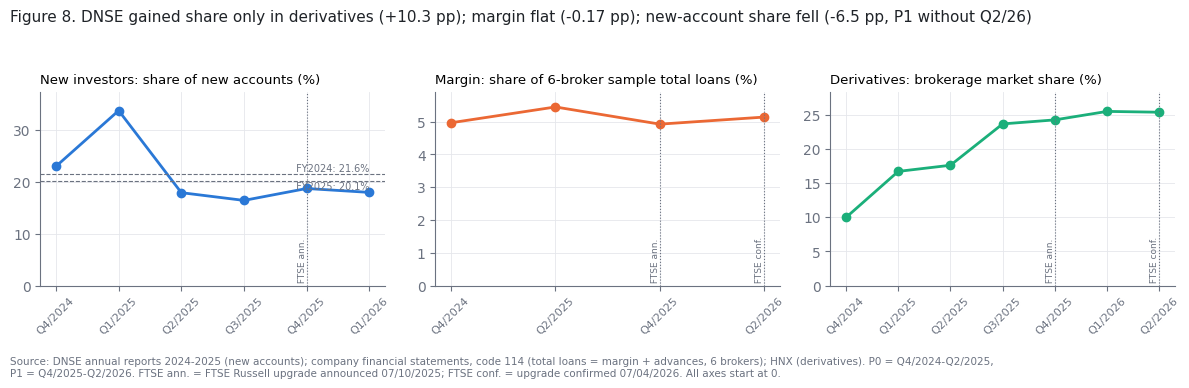

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=False)
qq = acq_off[acq_off.period.str.startswith("Q")]
SEG_COL = {"New investors": "#2a78d6", "Margin": "#eb6834", "Derivatives": "#1baf7a"}
axes[0].plot(qq.period, qq.share * 100, marker="o", color=SEG_COL["New investors"], lw=2, label="Quarterly")
for per in ["FY2024", "FY2025"]:
    v = acq_off.set_index("period").share[per] * 100
    axes[0].axhline(v, color=MUTED, lw=0.8, ls="--")
    axes[0].text(len(qq) - 1, v, f" {per}: {v:.1f}%", fontsize=7, color=MUTED, va="bottom" if per == "FY2024" else "top", ha="right")
axes[0].set_title("New investors: share of new accounts (%)", fontsize=9.5, loc="left")
axes[1].plot(list(mh_share.index), mh_share.values * 100, marker="o", color=SEG_COL["Margin"], lw=2)
axes[1].set_title("Margin: share of 6-broker sample total loans (%)", fontsize=9.5, loc="left")
qs = list(dse_ds.index)
axes[2].plot(qs, dse_ds.values * 100, marker="o", color=SEG_COL["Derivatives"], lw=2)
axes[2].set_title("Derivatives: brokerage market share (%)", fontsize=9.5, loc="left")
MILESTONES = {"Q4/2025": "FTSE ann.", "Q2/2026": "FTSE conf."}
for ax in axes:
    ax.set_ylim(bottom=0, top=ax.get_ylim()[1] * 1.08)
    ticks = [t.get_text() for t in ax.get_xticklabels()] or []
    xs = list(ax.get_lines()[0].get_xdata())
    for q, lab in MILESTONES.items():
        if q in xs:
            i = xs.index(q); ax.axvline(i, color=MUTED, lw=0.8, ls=":")
            ax.text(i, 0, " " + lab, fontsize=6.5, color=MUTED, rotation=90, va="bottom", ha="right")
    ax.tick_params(axis="x", rotation=45, labelsize=8)
dchg = momentum.set_index("segment").change_pp
fig.suptitle(f"Figure 8. DNSE gained share only in derivatives ({dchg['Derivatives']:+.1f} pp); margin flat ({dchg['Margin']:+.2f} pp); "
             f"new-account share fell ({dchg['New investors']:+.1f} pp, P1 without Q2/26)",
             x=0.01, ha="left", fontsize=11, color=INK)
footer(fig, "Source: DNSE annual reports 2024-2025 (new accounts); company financial statements, code 114 (total loans = margin + advances, "
            "6 brokers); HNX (derivatives). P0 = Q4/2024-Q2/2025, P1 = Q4/2025-Q2/2026. FTSE ann. = FTSE Russell upgrade announced 07/10/2025; "
            "FTSE conf. = upgrade confirmed 07/04/2026. All axes start at 0.")
fig.tight_layout(rect=(0, 0.08, 1, 0.93))
fig.savefig(FIG / "Fig08_B_market_share.png", dpi=200)
plt.show()

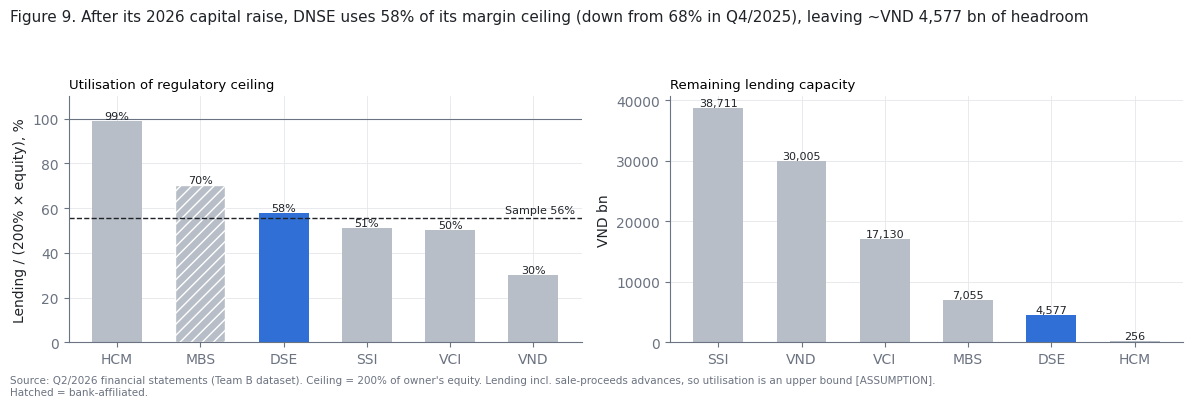

In [11]:
h = H2.drop(index="SAMPLE").sort_values("utilisation", ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bars = axes[0].bar(h.index, h.utilisation * 100, color=bar_colors(h.index), width=0.6)
for bar, t in zip(bars, h.index):
    if bs.set_index("ticker").at[t, "bank_affiliated"]:
        bar.set_hatch("///"); bar.set_edgecolor("white")
axes[0].axhline(H2.at["SAMPLE", "utilisation"] * 100, color=INK, lw=1, ls="--")
axes[0].text(len(h) - 0.5, H2.at["SAMPLE", "utilisation"] * 100 + 2,
             f"Sample {H2.at['SAMPLE','utilisation']:.0%}", ha="right", fontsize=8, color=INK)
axes[0].axhline(100, color=MUTED, lw=0.8)
axes[0].set_ylabel("Lending / (200% × equity), %")
axes[0].set_ylim(0, 110)
axes[0].set_title("Utilisation of regulatory ceiling", fontsize=9.5, loc="left")
axes[0].bar_label(bars, labels=[f"{x:.0%}" for x in h.utilisation], fontsize=8, color=INK)

h2 = h.sort_values("headroom_bn", ascending=False)
bars = axes[1].bar(h2.index, h2.headroom_bn, color=bar_colors(h2.index), width=0.6)
axes[1].bar_label(bars, labels=[f"{x:,.0f}" for x in h2.headroom_bn], fontsize=8, color=INK)
axes[1].set_ylabel("VND bn")
axes[1].set_title("Remaining lending capacity", fontsize=9.5, loc="left")
fig.suptitle(f"Figure 9. After its 2026 capital raise, DNSE uses {H2.at['DSE','utilisation']:.0%} of its margin ceiling "
             f"(down from {H4.at['DSE','utilisation']:.0%} in Q4/2025), leaving ~VND {H2.at['DSE','headroom_bn']:,.0f} bn of headroom",
             x=0.01, ha="left", fontsize=11, color=INK)
footer(fig, "Source: Q2/2026 financial statements (Team B dataset). Ceiling = 200% of owner's equity. "
            "Lending incl. sale-proceeds advances, so utilisation is an upper bound [ASSUMPTION]. Hatched = bank-affiliated.")
fig.tight_layout(rect=(0, 0.05, 1, 0.92))
fig.savefig(FIG / "Fig09_B1_margin_headroom.png", dpi=200)
plt.show()

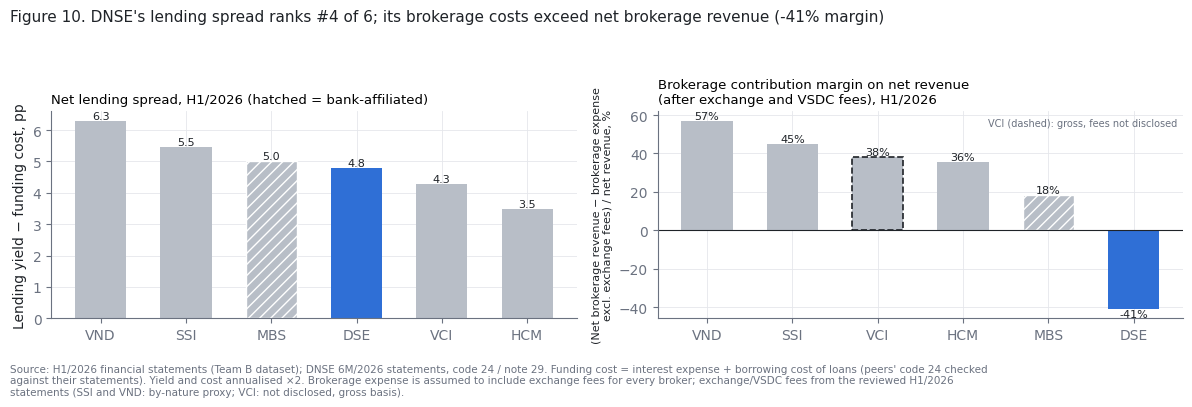

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
e = eff.sort_values("spread_A_pp", ascending=False)
bars = axes[0].bar(e.ticker, e.spread_A_pp, color=bar_colors(e.ticker), width=0.6)
BANK = set(bs.loc[bs.bank_affiliated, "ticker"])
for bar, t in zip(bars, e.ticker):
    if t in BANK: bar.set_hatch("///"); bar.set_edgecolor("white")
axes[0].bar_label(bars, labels=[f"{x:.1f}" for x in e.spread_A_pp], fontsize=8, color=INK)
axes[0].set_ylabel("Lending yield − funding cost, pp")
axes[0].set_title("Net lending spread, H1/2026 (hatched = bank-affiliated)",
                  fontsize=9.5, loc="left")
e2 = eff.sort_values("contrib_margin_used", ascending=False)
bars = axes[1].bar(e2.ticker, e2.contrib_margin_used * 100, color=bar_colors(e2.ticker), width=0.6)
for bar, t, basis in zip(bars, e2.ticker, e2.contrib_basis):
    if t in BANK: bar.set_hatch("///"); bar.set_edgecolor("white")
    if basis != "net": bar.set_linestyle("--"); bar.set_edgecolor(INK); bar.set_linewidth(1.2)
axes[1].bar_label(bars, labels=[f"{x:.0%}" for x in e2.contrib_margin_used], fontsize=8, color=INK)
axes[1].axhline(0, color=INK, lw=0.8)
axes[1].set_ylabel("(Net brokerage revenue − brokerage expense\nexcl. exchange fees) / net revenue, %", fontsize=8)
axes[1].set_title("Brokerage contribution margin on net revenue\n(after exchange and VSDC fees), H1/2026", fontsize=9.5, loc="left")
axes[1].text(0.99, 0.97, "VCI (dashed): gross, fees not disclosed", transform=axes[1].transAxes, fontsize=7, color=MUTED, ha="right", va="top")
ea = eff.set_index("ticker")
fig.suptitle(f"Figure 10. DNSE's lending spread ranks #{ea.at['DSE','rank_spread_A']} of 6; "
             f"its brokerage costs exceed net brokerage revenue ({ea.at['DSE','contrib_margin_used']:.0%} margin)",
             x=0.01, ha="left", fontsize=11, color=INK)
footer(fig, "Source: H1/2026 financial statements (Team B dataset); DNSE 6M/2026 statements, code 24 / note 29. Funding cost = interest "
            "expense + borrowing cost of loans (peers' code 24 checked against their statements). Yield and cost annualised ×2. "
            "Brokerage expense is assumed to include exchange fees for every broker; exchange/VSDC fees from the reviewed H1/2026 statements "
            "(SSI and VND: by-nature proxy; VCI: not disclosed, gross basis).")
fig.tight_layout(rect=(0, 0.11, 1, 0.92))
fig.savefig(FIG / "Fig10_B1_efficiency.png", dpi=200)
plt.show()

## 5b. Capability and price (2.4, with 2.5 merged in, per the Leader)

**Three-level scale (Leader, 26/9):** below the market = **0** · at the point of parity = **2.5** · superior = **5**.

**How it is measured** (per client group):
- *Features* – Table 3, versus SSI, VPS and TCBS. **Parity feature** = offered by at least 2 of 3 peers. **Differentiator** = DNSE has it and at most 1 of 3 peers do.
- *Price* (former 2.5) – DNSE's price versus the **median** of the peers in sheet `2.5_Pricing`: cheaper = +1, dearer = −1, equal = 0.
  New investors: stock brokerage fee (excl. exchange fee) · Margin: broadly applied rate · Derivatives: company fee at low volume.
- **Net score** = differentiators + price point − parity features DNSE lacks → negative = 0 · zero = 2.5 · positive = 5.
- Feature 2 (zero brokerage fee) duplicates the price item, so it is not counted twice. "Unknown" cells count as not offered.

In [13]:
cap = pd.read_csv(ROOT / "data/sources/2.4_capability_matrix.csv", encoding="utf-8-sig")
PEERS3 = ["SSI", "VPS", "TCBS"]

def feature_table(unknown_as_yes=False):
    c = cap.copy()
    v = c.available_Yes_No_Unknown.astype(str)
    c["has"] = v.str.startswith("Yes") | (unknown_as_yes & v.str.startswith("Unknown"))
    t = c.pivot_table(index=["segment", "feature_no", "feature"], columns="broker", values="has", aggfunc="first")
    t = t.drop(index=2, level="feature_no")
    t["n_peers"] = t[PEERS3].sum(axis=1)
    t["parity_gap"] = (t.n_peers >= 2) & ~t.DNSE.astype(bool)
    t["differentiator"] = (t.n_peers <= 1) & t.DNSE.astype(bool)
    t["minor_gap"] = (t.n_peers == 1) & ~t.DNSE.astype(bool)
    return t

px = pd.ExcelFile(ROOT / "data/raw/FBAR2_TEAM_B_DATASET_v2.xlsx")
pr = pd.read_excel(px, "2.5_Pricing", header=None)
eq = pr.iloc[1:7, [0, 3]].set_axis(["company", "fee"], axis=1).set_index("company").fee.astype(float)
eq.loc["TCBS"] = 0.0
mg = pr.iloc[12:18, [0, 2, 3]].set_axis(["company", "broad", "promo"], axis=1).set_index("company").astype(float)
dv = pr.iloc[23:29, [0, 1, 3]].set_axis(["company", "min_fee", "low_vol_fee"], axis=1).set_index("company")
dv["min_fee"] = pd.to_numeric(dv.min_fee, errors="coerce")
dv["low_vol_fee"] = pd.to_numeric(dv.low_vol_fee, errors="coerce")
log("D22", "2.5_Pricing", "D4 (TCBS)", "TCBS 0.03% is the exchange fee, not a brokerage fee",
    "TCBS brokerage fee set to 0 (Leader: ignore exchange fees)", 0.0003, 0.0)
fee3 = pd.read_csv(ROOT / "data/sources/derivatives_fee_3cols.csv", encoding="utf-8-sig")
fee3.to_csv(CLEAN / "2.4_derivatives_fee_3cols.csv", index=False)
chk = fee3.set_index("broker").company_fee_low_volume_vnd.rename({"DNSE": "DSE"})
for b in ["DSE", "VPS", "TCBS", "SSI"]:
    assert chk[b] == dv.low_vol_fee[b], b

def price_point(series):
    s = series.dropna(); med = s.drop("DSE").median(); d = s["DSE"]
    return (1 if d < med else -1 if d > med else 0), d, med

PRICE = {
    "base": {"New investors": eq, "Margin": mg.broad, "Derivatives": dv.low_vol_fee},
    "alt":  {"New investors": eq, "Margin": mg.promo, "Derivatives": dv.min_fee},
}

def to_score(net, diff=0):
    return 0.0 if net < 0 else 5.0 if (net > 0 and diff >= 1) else 2.5

def capability(price="base", unknown_as_yes=False):
    t = feature_table(unknown_as_yes)
    g = t.groupby(level="segment")[["parity_gap", "differentiator", "minor_gap"]].sum()
    rows = []
    for seg in SEGS:
        pp, d, med = price_point(PRICE[price][seg])
        net = int(g.at[seg, "differentiator"]) + pp - int(g.at[seg, "parity_gap"])
        rows.append(dict(segment=seg, parity_gaps=int(g.at[seg, "parity_gap"]), minor_gaps=int(g.at[seg, "minor_gap"]),
                         differentiators=int(g.at[seg, "differentiator"]), dse_price=d, peer_median=med,
                         price_point=pp, net=net, score=to_score(net, int(g.at[seg, "differentiator"]))))
    return pd.DataFrame(rows).set_index("segment"), t

SEGS = ["New investors", "Margin", "Derivatives"]
cap24, feat = capability()
cap24_alt, _ = capability(price="alt")
cap24_unk, _ = capability(unknown_as_yes=True)
cap24.to_csv(CLEAN / "2.4_capability_price_scored.csv")
feat.reset_index().to_csv(CLEAN / "2.4_capability_matrix_scored.csv", index=False)
feat[feat.parity_gap | feat.minor_gap | feat.differentiator].reset_index().to_csv(CLEAN / "2.4_capability_gaps.csv", index=False)
display(cap24)
print("Alternative prices (margin promo, derivatives top tier):", cap24_alt.score.to_dict())

,parity_gaps,minor_gaps,differentiators,dse_price,peer_median,price_point,net,score
segment,,,,,,,,
New investors,0,1,0,0.000,0.001,1,1,2.5
Margin,0,0,0,0.125,0.130,1,1,2.5
Derivatives,0,0,0,1000.000,1500.000,1,1,2.5


Alternative prices (margin promo, derivatives top tier): {'New investors': 2.5, 'Margin': 2.5, 'Derivatives': 0.0}


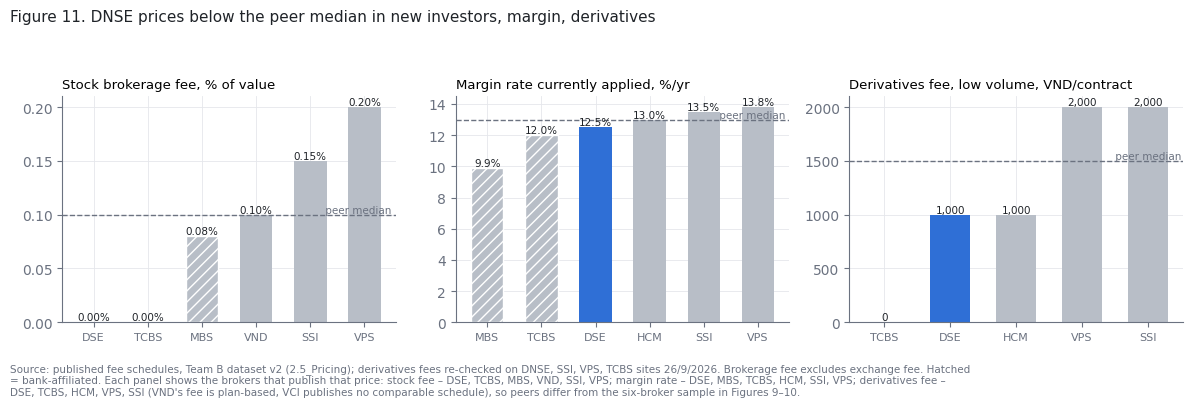

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
BANKS = {"MBS", "TCBS"}
panels = [("New investors", eq * 100, "Stock brokerage fee, % of value", "{:.2f}%", 100),
          ("Margin", mg.broad * 100, "Margin rate currently applied, %/yr", "{:.1f}%", 100),
          ("Derivatives", dv.low_vol_fee.dropna(), "Derivatives fee, low volume, VND/contract", "{:,.0f}", 1)]
for ax, (seg, ser, ttl, fmt, k) in zip(axes, panels):
    ser = ser.sort_values()
    bars = ax.bar(ser.index, ser.values, color=[ACCENT if c == "DSE" else PEER for c in ser.index], width=0.6)
    for bar, cpy in zip(bars, ser.index):
        if cpy in BANKS: bar.set_hatch("///"); bar.set_edgecolor("white")
    ax.bar_label(bars, labels=[fmt.format(v) for v in ser.values], fontsize=7.5, color=INK)
    ax.axhline(cap24.at[seg, "peer_median"] * k, color=MUTED, ls="--", lw=1)
    ax.text(len(ser) - 0.5, cap24.at[seg, "peer_median"] * k, " peer median", va="bottom", ha="right", fontsize=7.5, color=MUTED)
    ax.set_title(ttl, fontsize=9.5, loc="left")
    ax.tick_params(axis="x", labelsize=8)
below = [s.lower() for s in SEGS if cap24.at[s, "price_point"] == 1]
fig.suptitle(f"Figure 11. DNSE prices below the peer median in {', '.join(below) if below else 'no group'}",
             x=0.01, ha="left", fontsize=11, color=INK)
footer(fig, "Source: published fee schedules, Team B dataset v2 (2.5_Pricing); derivatives fees re-checked on DNSE, SSI, VPS, TCBS sites 26/9/2026. "
            "Brokerage fee excludes exchange fee. Hatched = bank-affiliated. Each panel shows the brokers that publish that price: stock fee – DSE, TCBS, MBS, VND, SSI, VPS; "
            "margin rate – DSE, MBS, TCBS, HCM, SSI, VPS; derivatives fee – DSE, TCBS, HCM, VPS, SSI (VND's fee is plan-based, VCI publishes no comparable schedule), "
            "so peers differ from the six-broker sample in Figures 9–10.")
fig.tight_layout(rect=(0, 0.11, 1, 0.92))
fig.savefig(FIG / "Fig11_B_competition_price.png", dpi=200)
plt.show()

## 6. Table 4 – Axis-2 scores

| Measure | Indicator | Rule |
|---|---|---|
| 2.1 Momentum | Change in DSE's share, P0 → P1 (pp) | ≤ −5 → 1 · (−5, −1] → 2 · (−1, +1] → 3 · (+1, +5] → 4 · > +5 → 5 |
| 2.2 Headroom | Growth left before the binding limit (g) | < 10% → 1 · < 25% → 2 · < 50% → 3 · < 100% → 4 · ≥ 100% → 5 |
| 2.3 Efficiency | DSE's rank among 6 brokers | 1 → 5 · 2 → 4 · 3–4 → 3 · 5 → 2 · 6 → 1 |
| 2.4 Capability & price | Net position vs the market (section 5b) | below = 0 · parity = 2.5 · superior = 5 |

Limit used for g: new investors – brokerage share reaching account share; margin – 200%-of-equity ceiling; derivatives – share reaching VPS.
Derivatives efficiency: rank of the low-volume fee per contract (higher fee = more revenue per contract); the old judgement score of 2 is tested in the sensitivity check.
New investors: P1 has only Q4/2025 and Q1/2026 (DNSE has not published Q2/2026).

In [15]:
SEGS = ["New investors", "Margin", "Derivatives"]

def score_change(pp):
    return 1 if pp <= -5 else 2 if pp <= -1 else 3 if pp <= 1 else 4 if pp <= 5 else 5

def score_room(g):
    return 1 if g < .10 else 2 if g < .25 else 3 if g < .50 else 4 if g < 1.0 else 5

def score_rank(r, n=6):
    return {1: 5, 2: 4, 3: 3, 4: 2, 5: 1}[int(r)] if n == 5 else {1: 5, 2: 4, 3: 3, 4: 3, 5: 2, 6: 1}[int(r)]

ni = newinv
acc_share = ni["Total_Account_Share_2025"]
HOSE_10TH_Q2_26 = 0.0294
log("D26", "2.2_NewInvestors", "B6", "1.92% is Mirae Asset's H1/2026 derivatives share, not DNSE's stock-brokerage share",
    "DNSE is outside HOSE's top 10 → use the 10th broker's share (2.94%, Q2/2026) as an upper bound (MASTERPLAN)",
    ni["Total_Stock_Brokerage_Share_2025"], HOSE_10TH_Q2_26)
brk_share = HOSE_10TH_Q2_26
vps_q2 = ds[(ds.quarter == "Q2/2026") & (ds.broker == "VPS")].share.iloc[0]
ROOM_DESC = {
    "New investors": "brokerage share catching up with account share",
    "Margin": "lending reaching the 200%-of-equity ceiling",
    "Derivatives": "derivatives share catching up with leader VPS",
}

fee_rank = dv.low_vol_fee.dropna().rank(ascending=False, method="min")
DERIV_EFF_RULE = score_rank(fee_rank["DSE"], n=len(fee_rank))

def build_scores(mom, spread_rank_col="rank_spread_A", deriv_eff=None, brk=brk_share, cap_t=None):
    deriv_eff = DERIV_EFF_RULE if deriv_eff is None else deriv_eff
    cap_t = cap24 if cap_t is None else cap_t
    room = {"New investors": acc_share / brk - 1,
            "Margin": H2.at["DSE", "headroom_vs_book"],
            "Derivatives": vps_q2 / dse_ds["Q2/2026"] - 1}
    rows = []
    for seg in SEGS:
        rows.append((seg, "2.1 Momentum", score_change(mom[seg]), f"DSE share {mom[seg]:+.2f} pp (base window)"))
        rows.append((seg, "2.2 Headroom", score_room(room[seg]),
                     f"Room {room[seg]:.0%} before {ROOM_DESC[seg]}"))
    rows.append(("New investors", "2.3 Efficiency", score_rank(ea.at["DSE", "rank_contrib"]),
                 f"Brokerage contribution margin on net revenue {ea.at['DSE','contrib_margin_used']:.1%}, rank {ea.at['DSE','rank_contrib']}/6"))
    rows.append(("Margin", "2.3 Efficiency", score_rank(ea.at["DSE", spread_rank_col]),
                 f"Net lending spread {ea.at['DSE', spread_rank_col.replace('rank_', '') + '_pp']:.1f} pp, rank {ea.at['DSE', spread_rank_col]}/6"))
    rows.append(("Derivatives", "2.3 Efficiency", deriv_eff,
                 f"Low-volume fee per contract ranks #{int(fee_rank['DSE'])} of {len(fee_rank)} (higher fee = more revenue per contract)"))
    for seg in SEGS:
        r = cap_t.loc[seg]
        rows.append((seg, "2.4 Capability & price", r.score,
                     f"{int(r.parity_gaps)} must-have gap(s), {int(r.differentiators)} differentiator(s), price {'below' if r.price_point > 0 else 'above' if r.price_point < 0 else 'at'} peer median; "
                     + {5.0: "differentiated (5)", 2.5: ("no differentiator → parity (2.5)" if r.differentiators == 0 else "parity (2.5)"), 0.0: "below market (0)"}[r.score]))
    return pd.DataFrame(rows, columns=["segment", "measure", "score", "evidence"])

mom_base = momentum.set_index("segment").change_pp
scores = build_scores(mom_base)

bang4 = scores.pivot(index="segment", columns="measure", values="score").reindex(SEGS)
bang4["Axis 2 score"] = bang4.mean(axis=1, skipna=True)
bang4["n_measures"] = bang4.drop(columns="Axis 2 score").notna().sum(axis=1)
scores.to_csv(CLEAN / "Table4_axis2_evidence.csv", index=False)
bang4.to_csv(CLEAN / "Table4_axis2_scores.csv")
display(bang4.round(2))
with pd.option_context("display.max_colwidth", 120):
    display(scores[scores.score.notna()])

measure,2.1 Momentum,2.2 Headroom,2.3 Efficiency,2.4 Capability & price,Axis 2 score,n_measures
segment,,,,,,
New investors,1.0,5.0,1.0,2.5,2.38,4
Margin,3.0,4.0,3.0,2.5,3.12,4
Derivatives,5.0,3.0,3.0,2.5,3.38,4


,segment,measure,score,evidence
0,New investors,2.1 Momentum,1.0,DSE share -6.55 pp (base window)
1,New investors,2.2 Headroom,5.0,Room 342% before brokerage share catching up with account share
2,Margin,2.1 Momentum,3.0,DSE share -0.17 pp (base window)
3,Margin,2.2 Headroom,4.0,Room 73% before lending reaching the 200%-of-equity ceiling
4,Derivatives,2.1 Momentum,5.0,DSE share +10.27 pp (base window)
5,Derivatives,2.2 Headroom,3.0,Room 33% before derivatives share catching up with leader VPS
6,New investors,2.3 Efficiency,1.0,"Brokerage contribution margin on net revenue -40.8%, rank 6/6"
7,Margin,2.3 Efficiency,3.0,"Net lending spread 4.8 pp, rank 4/6"
8,Derivatives,2.3 Efficiency,3.0,Low-volume fee per contract ranks #3 of 5 (higher fee = more revenue per contract)
9,New investors,2.4 Capability & price,2.5,"0 must-have gap(s), 0 differentiator(s), price below peer median; no differentiator → parity (2.5)"


### 6.1 Sensitivity check (axis-2 part of Table PL2)

In [16]:
def axis2(sc, drop=None):
    s = sc if drop is None else sc[sc.measure != drop]
    return s.groupby("segment").score.mean().reindex(SEGS)

def leaders(s):
    return " = ".join(s[np.isclose(s, s.max())].index)

mom_alt = mom_all[~mom_all.is_base].set_index("segment").change_pp
scen = {
    "Base": build_scores(mom_base),
    "Alt momentum windows (new inv. FY24→FY25, margin 6M, deriv 12M)": build_scores(mom_alt),
    "Derivatives efficiency = 2 (old judgement)": build_scores(mom_base, deriv_eff=2),
    "2.4 alt prices (margin promo, deriv top tier)": build_scores(mom_base, cap_t=cap24_alt),
}
rows = {k: axis2(v) for k, v in scen.items()}
for m in ["2.1 Momentum", "2.2 Headroom", "2.3 Efficiency", "2.4 Capability & price"]:
    rows[f"Drop {m}"] = axis2(scen["Base"], drop=m)
sens = pd.DataFrame(rows).T
sens["leader"] = sens[SEGS].apply(leaders, axis=1)
sens.to_csv(CLEAN / "Table_PL2_axis2_sensitivity.csv")
display(sens.round(2))
base_lead = sens.at["Base", "leader"]
print(f"Base leader: {base_lead}. Same leader in {(sens.leader == base_lead).sum()}/{len(sens)} scenarios.")

thr = pd.DataFrame([{"headroom score falls to": s, "if DSE stock-brokerage share exceeds": acc_share / (1 + g)}
                    for s, g in [(4, 1.0), (3, 0.5), (2, 0.25)]])
thr["if DSE stock-brokerage share exceeds"] = thr["if DSE stock-brokerage share exceeds"].map("{:.2%}".format)
display(thr)
print(f"Current value {brk_share:.2%} → the new-investor headroom score only changes if the true share is "
      f"above {acc_share/2:.1%}, i.e. {acc_share/2/brk_share:.1f}× the reported figure.")

segment,New investors,Margin,Derivatives,leader
Base,2.38,3.12,3.38,Derivatives
"Alt momentum windows (new inv. FY24→FY25, margin 6M, deriv 12M)",2.62,3.12,3.38,Derivatives
Derivatives efficiency = 2 (old judgement),2.38,3.12,3.12,Margin = Derivatives
"2.4 alt prices (margin promo, deriv top tier)",2.38,3.12,2.75,Margin
Drop 2.1 Momentum,2.83,3.17,2.83,Margin
Drop 2.2 Headroom,1.50,2.83,3.50,Derivatives
Drop 2.3 Efficiency,2.83,3.17,3.50,Derivatives
Drop 2.4 Capability & price,2.33,3.33,3.67,Derivatives


Base leader: Derivatives. Same leader in 5/8 scenarios.


,headroom score falls to,if DSE stock-brokerage share exceeds
0,4,6.50%
1,3,8.67%
2,2,10.40%


Current value 2.94% → the new-investor headroom score only changes if the true share is above 6.5%, i.e. 2.2× the reported figure.


### 6.2 Derivatives market concentration (context, not scored)

In [17]:
qorder = ["Q4/2024", "Q1/2025", "Q2/2025", "Q3/2025", "Q4/2025", "Q1/2026", "Q2/2026"]
conc = ds.groupby("quarter").apply(lambda d: pd.Series({
    "top2_share": d.nsmallest(2, "rank").share.sum(),
    "top5_share": d.nsmallest(5, "rank").share.sum(),
    "hhi_top10": ((d.share * 100) ** 2).sum(),
    "dse_rank": int(d.loc[d.broker == "DSE", "rank"].iloc[0]),
})).reindex(qorder)
conc.to_csv(CLEAN / "2.5_derivatives_concentration.csv")
display(conc.round(3))
print("HHI > 2,500 = highly concentrated (US DOJ convention); computed on top-10 shares only, so a lower bound.")

,top2_share,top5_share,hhi_top10,dse_rank
quarter,,,,
Q4/2024,0.658,0.818,3336.426,2.0
Q1/2025,0.674,0.833,2959.532,2.0
Q2/2025,0.640,0.809,2594.613,2.0
Q3/2025,0.598,0.784,2032.768,2.0
Q4/2025,0.581,0.795,1937.826,2.0
Q1/2026,0.588,0.800,1966.023,2.0
Q2/2026,0.592,0.815,2005.921,2.0


HHI > 2,500 = highly concentrated (US DOJ convention); computed on top-10 shares only, so a lower bound.


## 7. Method and findings summary, source register

A short method-and-findings summary is generated from the outputs above and saved to `report/findings_axis2_draft.md`.

In [18]:
e = ea
peer_med_yield = eff[eff.ticker != "DSE"].lending_yield.median()
mb = momentum.set_index("segment")
n_fixed = sum(1 for x in LOG)

lines = []
lines.append("# Team B – axis 2 (supply side): method and findings (auto-generated from notebook/B1_axis2_supply_side.ipynb)\n")
lines.append("## Method\n")
lines.append("- **Sample:** DSE, SSI, VND, HCM, VCI, MBS (company data, financial statements Q4/2024–Q2/2026); SSI, VPS, TCBS for features; HNX for derivatives shares.")
lines.append("- **Lending = total loans (FS code 114)** for every broker, because DNSE does not split margin loans from sale-proceeds advances.")
lines.append("- **Measures:** 2.1 momentum (share change, P0 = Q4/2024–Q2/2025 vs P1 = Q4/2025–Q2/2026), 2.2 headroom (growth left before a binding limit), "
             "2.3 efficiency (DSE rank among six brokers; derivatives among five with published fees), scored 1–5; "
             "2.4 capability & price (net position vs peers), scored 0 / 2.5 / 5, where 5 requires at least one differentiator.")
lines.append(f"- **Checks:** {val.match.sum()} spreadsheet formulas re-computed and matched; quarterly figures reconcile to cumulative FS totals; "
             f"{len(LOG)} data fixes logged.\n")
lines.append("## Findings\n")
lines.append(f"- **Momentum:** derivatives share {mb.at['Derivatives','start_val']:.1%} → {mb.at['Derivatives','end_val']:.1%}; "
             f"margin (share of sample loans) {mb.at['Margin','start_val']:.1%} → {mb.at['Margin','end_val']:.1%}; "
             f"new accounts {mb.at['New investors','start_val']:.1%} → {mb.at['New investors','end_val']:.1%} (P1 = Q4/2025–Q1/2026).")
lines.append(f"- **Headroom:** margin ceiling used {H2.at['DSE','utilisation']:.0%} (Q2/2026), about VND {H2.at['DSE','headroom_bn']:,.0f} bn left.")
lines.append(f"- **Efficiency:** lending spread {e.at['DSE','spread_A_pp']:.1f} pp, rank {e.at['DSE','rank_spread_A']}/6; "
             f"brokerage contribution margin on net revenue {e.at['DSE','contrib_margin_used']:.1%}, rank {e.at['DSE','rank_contrib']}/6.")
lines.append("- **Capability & price:** " + "; ".join(
    f"{s.lower()} {cap24.at[s,'score']:g} (net {int(cap24.at[s,'net']):+d}, {int(cap24.at[s,'differentiators'])} differentiator)" for s in SEGS) + ".")
b = bang4["Axis 2 score"]; order = b.sort_values(ascending=False)
ax2 = f"{order.index[0].lower()} {order.iloc[0]:.3f}"
for i in range(1, 3):
    ax2 += (" = " if np.isclose(order.iloc[i], order.iloc[i-1]) else " > ") + f"{order.index[i].lower()} {order.iloc[i]:.3f}"
lines.append(f"- **Axis 2:** " + ax2
             + f". Leader(s) by scenario: " + "; ".join(f"{k}: {v}" for k, v in sens.leader.value_counts().items()) + ".\n")
lines.append("## Limitations\n")
lines.append("- Derivatives efficiency ranks published fees, not realised revenue; 2.4 uses three peers for features and published prices.")
lines.append("- DNSE has not published Q2/2026 new accounts, so new-investor P1 covers Q4/2025–Q1/2026 only.")
lines.append(f"- DNSE is outside HOSE's top 10; the 10th broker's share ({brk_share:.2%}, Q2/2026) is used as an upper bound. The headroom score only changes if DNSE's true share exceeds {acc_share/2:.1%}.")
lines.append("- Mixed 1–5 and 0/2.5/5 scales are averaged with equal weight, as agreed with the team leader.")
lines.append("- New-investor headroom compares DNSE's 2025 account share (13%) with an upper bound for its Q2/2026 HOSE brokerage share (2.94%): different periods and bases.")
lines.append("- The same derivatives fee enters twice in opposite directions: a higher fee ranks better on efficiency (2.3), a lower fee counts as a price advantage (2.4).")
lines.append("- Lending share uses Q4 and Q2 of each period only, and total loans (margin + advances) for every broker.")
lines.append("- Peers' exchange fees for SSI and VND are proxies; VCI does not disclose them, so its brokerage margin is on gross revenue.\n")
(ROOT / "report/findings_axis2_draft.md").write_text("\n".join(lines), encoding="utf-8")
print("\n".join(lines))

sources = pd.DataFrame([
    ("P1", "Vietstock 16/01/2026 – DNSE Q4/2025 results (loans + advances 5,832 bn)",
     "https://vietstock.vn/2026/01/dnse-dat-ky-luc-du-no-cho-vay-ky-quy-va-ung-truoc-tien-ban-737-1391525.htm", "2026-09-25", "VND bn", "C", "verified"),
    ("P2", "Vietstock 18/04/2026 – DNSE Q1/2026 results (loans + advances 5,910 bn)",
     "https://vietstock.vn/2026/04/dnse-noi-tiep-da-tang-truong-doanh-thu-va-du-no-margin-737-1429717.htm", "2026-09-25", "VND bn", "C", "verified"),
    ("P3", "Tin nhanh chứng khoán 21/07/2026 – DNSE Q2/2026 results (6,303 bn; H1 derivatives share 25.47%)",
     "https://www.tinnhanhchungkhoan.vn/du-no-cho-vay-ky-quy-va-ung-truoc-tien-ban-cua-dnse-dat-ky-luc-tren-6300-ty-dong-post394383.html", "2026-09-25", "VND bn", "C", "verified"),
    ("F1", "DNSE financial statements 6M/2026, income statement code 24 + note 29 (borrowing cost of loans 239.96 bn)",
     "https://ir.dnse.com.vn/vi/ctype-finance_report", "2026-09-25", "VND", "A", "verified by BA (check.pdf)"),
    ("F2", "DNSE Annual Report 2025 (FS notes 7c, 27; new accounts Hinh 21; HNX share 3.12%; bond DSE125018 8.3%)",
     "https://ir.dnse.com.vn/vi/ctype-yearly_report", "2026-09-26", "VND", "A", "verified"),
    ("F3", "DNSE Annual Report 2024 (new accounts 2024; 21.6% share of new accounts)",
     "https://ir.dnse.com.vn/vi/ctype-yearly_report", "2026-09-26", "accounts", "A", "verified"),
    ("F4", "SSI financial statements Q4/2024, Q2/2025, Q4/2025, Q2/2026 (code 114 total loans, code 06, code 24)",
     "https://www.ssi.com.vn/quan-he-nha-dau-tu/bao-cao-tai-chinh", "2026-09-26", "VND", "A", "verified"),
    ("F5", "VND financial statements Q4/2024, Q2/2025, Q4/2025, Q1-Q2/2026 (code 114, code 06, code 24 + note 27)",
     "https://24hmoney.vn/stock/VND/financial-report", "2026-09-26", "VND", "A", "verified"),
    ("F6", "HCM financial statements Q4/2024, Q2/2025, Q4/2025 (code 114, code 06, code 24 borrowing cost)",
     "https://24hmoney.vn/stock/HCM/financial-report", "2026-09-26", "VND", "A", "verified"),
    ("F7", "VCI financial statements Q4/2024, Q2/2025, Q4/2025 (code 114, code 06, code 24)",
     "https://24hmoney.vn/stock/VCI/financial-report", "2026-09-26", "VND", "A", "verified"),
    ("F8", "MBS financial statements Q4/2024, Q2/2025, Q4/2025, Q1-Q2/2026 (code 114, code 06, code 24)",
     "https://24hmoney.vn/stock/MBS/financial-report", "2026-09-26", "VND", "A", "verified"),
] + [(sid, "Team B dataset source ID – details pending", "", "", "", "", "PENDING BA")
     for sid in ["S5", "S6", "S7", "M1.1", "M1.2", "M2.1", "M2.2", "M3.1", "M3.2", "M4.1", "M4.2",
                 "A1", "A2"]] + [
    ("F9", "Quarterly statements Q3/2025-Q2/2026, six brokers (codes 06, 03, 114) – data/sources/bctc_quarterly_4Q_official.csv", "company IR sites", "2026-09-26", "VND", "A", "verified"),
    ("D1-D7", "HNX quarterly derivatives brokerage shares – data/sources/derivatives_share_links.csv", "hnx.vn", "2026-09-26", "%", "A", "verified"),
    ("V1", "VSDC / DNSE new accounts Q4/2024, Q1/2026, Q2/2026 (via press) – data/sources/new_accounts_vsdc.csv", "nhadautu.vn; baomoi.com", "2026-09-26", "accounts", "C", "verified"),
    ("FEE", "Derivatives fee schedules DNSE/VPS/TCBS/SSI + consolidated circular 30/2026/VBHN-BTC", "see derivatives_fee_3cols.csv", "2026-09-26", "VND/contract", "A", "verified (SSI from BA)")],
    columns=["source_id", "description", "url", "accessed", "unit", "grade", "status"])
sources.to_csv(CLEAN / "B_sources.csv", index=False)
print(f"Sources table: {len(sources)} rows ({(sources.status != 'PENDING BA').sum()} verified, "
      f"{(sources.status == 'PENDING BA').sum()} pending BA)")

# Team B – axis 2 (supply side): method and findings (auto-generated from notebook/B1_axis2_supply_side.ipynb)

## Method

- **Sample:** DSE, SSI, VND, HCM, VCI, MBS (company data, financial statements Q4/2024–Q2/2026); SSI, VPS, TCBS for features; HNX for derivatives shares.
- **Lending = total loans (FS code 114)** for every broker, because DNSE does not split margin loans from sale-proceeds advances.
- **Measures:** 2.1 momentum (share change, P0 = Q4/2024–Q2/2025 vs P1 = Q4/2025–Q2/2026), 2.2 headroom (growth left before a binding limit), 2.3 efficiency (DSE rank among six brokers; derivatives among five with published fees), scored 1–5; 2.4 capability & price (net position vs peers), scored 0 / 2.5 / 5, where 5 requires at least one differentiator.
- **Checks:** 81 spreadsheet formulas re-computed and matched; quarterly figures reconcile to cumulative FS totals; 22 data fixes logged.

## Findings

- **Momentum:** derivatives share 14.8% → 25.0%; margin (share of sample loans) 5.2%

## 8. Hand-offs

- **8.1** Quarterly broker file for the Leader (`L_bctc_ctck_quarterly.csv`, Q3/2025–Q2/2026, codes 06/03/114), long-format dataset and data dictionary.
- **8.2** DNSE quarterly figures (for the Leader: Figures I2, I3 and Table PL1).

In [19]:
SRC_BA = "Team B dataset (BA) – source ID pending"
SRC_F1 = "DNSE FS 6M/2026, IS code 24 / note 29 (via BA)"
recs = []
def add(t, period, var, val, unit, src):
    recs.append(dict(ticker=t, period=period, variable=var, value=val, unit=unit, source=src))

for _, r in bs.iterrows():
    add(r.ticker, "Q4/2025", "equity", r.equity_q4_25, "VND bn", SRC_BA)
    add(r.ticker, "Q2/2026", "equity", r.equity_q2_26, "VND bn", SRC_BA)
    add(r.ticker, "Q4/2025", "financial_debt", r.debt_q4_25, "VND bn", SRC_BA)
    add(r.ticker, "Q2/2026", "financial_debt", r.debt_q2_26, "VND bn", SRC_BA)
    add(r.ticker, "Q2/2026", "cash", r.cash_q2_26, "VND bn", SRC_BA)
    add(r.ticker, "H1/2026", "interest_expense", r.int_exp_h1_26, "VND bn", SRC_BA)
    add(r.ticker, "static", "bank_affiliated", float(r.bank_affiliated), "0/1", SRC_BA)
for _, r in lend.iterrows():
    add(r.ticker, "Q4/2025", "lending_total", r.lending_q4_25, "VND bn", SRC_BA)
    add(r.ticker, "Q2/2026", "lending_total", r.lending_q2_26, "VND bn", SRC_BA)
    add(r.ticker, "H1/2026", "rev_lending", r.lending_income_h1_26, "VND bn", SRC_BA)
    add(r.ticker, "H1/2026", "borrow_cost_loans", r.other_borrow_cost_h1_26, "VND bn",
        SRC_F1 if r.ticker == "DSE" else "Not separated yet (set to 0) – R1")
for _, r in brk.iterrows():
    for per, rv, ex in [("H1/2025", r.brk_rev_h1_25, r.brk_exp_h1_25), ("H1/2026", r.brk_rev_h1_26, r.brk_exp_h1_26)]:
        add(r.ticker, per, "rev_brokerage", rv, "VND bn", SRC_BA)
        add(r.ticker, per, "exp_brokerage", ex, "VND bn", SRC_BA)
for _, r in mh.iterrows():
    add(r.ticker, r.quarter, "margin_reported", r.margin_bn, "VND bn", f"BA source {r.source_id}")

L_long = pd.DataFrame(recs)
L_long["in_fixed_sample"] = L_long.ticker.isin(TICKERS)
L_long.to_csv(CLEAN / "B_dataset_long.csv", index=False)

Lq = bq.rename(columns={"rev_brokerage_bn": "rev_brokerage_code06_bn", "int_loans_receivables_bn": "int_loans_receivables_code03_bn",
                        "total_loans_bn": "total_loans_code114_bn"})
Lq = Lq[["ticker", "quarter", "rev_brokerage_code06_bn", "int_loans_receivables_code03_bn", "total_loans_code114_bn"]]
tot = Lq.groupby("quarter", as_index=False).sum(numeric_only=True).assign(ticker="SAMPLE_TOTAL")
Lq = pd.concat([Lq, tot], ignore_index=True)
Lq["quarter"] = pd.Categorical(Lq.quarter, QTRS, ordered=True)
Lq["_o"] = Lq.ticker.map({t: i for i, t in enumerate(TICKERS + ["SAMPLE_TOTAL"])})
Lq = Lq.sort_values(["quarter", "_o"]).drop(columns="_o").reset_index(drop=True)
Lq["dse_share_of_sample_loans"] = np.where(Lq.ticker == "DSE", Lq.total_loans_code114_bn /
    Lq.quarter.map(tot.set_index("quarter").total_loans_code114_bn).astype(float), np.nan)
Lq["source"] = np.where(Lq.ticker == "SAMPLE_TOTAL", "sum of 6 brokers",
    "Company FS (consolidated where published), see data/sources/bctc_quarterly_4Q_official.csv")
Lq["unit"] = "VND bn; code 06/03 = quarter flow, code 114 = end of quarter"
Lq.to_csv(CLEAN / "L_bctc_ctck_quarterly.csv", index=False)
display(Lq.round(1))

dictionary = pd.DataFrame([
    ("equity", "Total owners' equity", "VND bn", "Quarter-end", "Balance sheet – owners' equity"),
    ("financial_debt", "Short- and long-term borrowings and finance leases + bonds issued", "VND bn", "Quarter-end", "Balance sheet"),
    ("cash", "Cash and cash equivalents", "VND bn", "Quarter-end", "Balance sheet"),
    ("interest_expense", "Interest expense (financial expenses line)", "VND bn", "6 months", "Income statement – financial expenses"),
    ("borrow_cost_loans", "Borrowing cost of loans = code 24 less loan-impairment provision", "VND bn", "6 months", "Income statement code 24 + provision note"),
    ("lending_total", "Total loans = margin loans + sale-proceeds advances (agreed definition, D01)", "VND bn", "Quarter-end", "Balance sheet – loans"),
    ("margin_reported", "Margin balance as recorded by the BA; definition differs across brokers (D01) – reference only", "VND bn", "Quarter-end", "Mixed"),
    ("rev_lending", "Interest from loans and receivables (incl. advances)", "VND bn", "6 months", "Income statement"),
    ("rev_brokerage", "Securities brokerage revenue", "VND bn", "6 months", "Income statement"),
    ("exp_brokerage", "Securities brokerage expense", "VND bn", "6 months", "Income statement"),
    ("bank_affiliated", "Parent company is a bank (1 = yes)", "0/1", "Static", "Company website"),
], columns=["variable", "definition", "unit", "period_type", "fs_line"])
dictionary.to_csv(CLEAN / "B_data_dictionary.csv", index=False)
print(f"B_dataset_long.csv: {len(L_long)} rows, {L_long.variable.nunique()} variables, {L_long.ticker.nunique()} brokers")
display(dictionary)

variable,ticker,quarter,rev_brokerage_code06_bn,int_loans_receivables_code03_bn,total_loans_code114_bn,dse_share_of_sample_loans,source,unit
0,DSE,Q3/2025,156.2,171.2,5750.1,0.1,"Company FS (consolidated where published), see...","VND bn; code 06/03 = quarter flow, code 114 = ..."
1,SSI,Q3/2025,921.8,1006.0,39231.4,NaN,"Company FS (consolidated where published), see...","VND bn; code 06/03 = quarter flow, code 114 = ..."
2,VND,Q3/2025,387.5,387.9,14843.5,NaN,"Company FS (consolidated where published), see...","VND bn; code 06/03 = quarter flow, code 114 = ..."
3,HCM,Q3/2025,506.7,641.6,20215.7,NaN,"Company FS (consolidated where published), see...","VND bn; code 06/03 = quarter flow, code 114 = ..."
4,VCI,Q3/2025,372.1,313.8,13944.7,NaN,"Company FS (consolidated where published), see...","VND bn; code 06/03 = quarter flow, code 114 = ..."
5,MBS,Q3/2025,369.6,408.1,15698.2,NaN,"Company FS (consolidated where published), see...","VND bn; code 06/03 = quarter flow, code 114 = ..."
6,SAMPLE_TOTAL,Q3/2025,2713.7,2928.5,109683.7,NaN,sum of 6 brokers,"VND bn; code 06/03 = quarter flow, code 114 = ..."
7,DSE,Q4/2025,125.0,185.9,5832.2,0.0,"Company FS (consolidated where published), see...","VND bn; code 06/03 = quarter flow, code 114 = ..."
8,SSI,Q4/2025,628.5,1098.4,38940.1,NaN,"Company FS (consolidated where published), see...","VND bn; code 06/03 = quarter flow, code 114 = ..."
9,VND,Q4/2025,231.0,407.1,14319.1,NaN,"Company FS (consolidated where published), see...","VND bn; code 06/03 = quarter flow, code 114 = ..."


B_dataset_long.csv: 114 rows, 11 variables, 6 brokers


,variable,definition,unit,period_type,fs_line
0,equity,Total owners' equity,VND bn,Quarter-end,Balance sheet – owners' equity
1,financial_debt,Short- and long-term borrowings and finance le...,VND bn,Quarter-end,Balance sheet
2,cash,Cash and cash equivalents,VND bn,Quarter-end,Balance sheet
3,interest_expense,Interest expense (financial expenses line),VND bn,6 months,Income statement – financial expenses
4,borrow_cost_loans,Borrowing cost of loans = code 24 less loan-im...,VND bn,6 months,Income statement code 24 + provision note
5,lending_total,Total loans = margin loans + sale-proceeds adv...,VND bn,Quarter-end,Balance sheet – loans
6,margin_reported,Margin balance as recorded by the BA; definiti...,VND bn,Quarter-end,Mixed
7,rev_lending,Interest from loans and receivables (incl. adv...,VND bn,6 months,Income statement
8,rev_brokerage,Securities brokerage revenue,VND bn,6 months,Income statement
9,exp_brokerage,Securities brokerage expense,VND bn,6 months,Income statement


### 8.2 DNSE quarterly figures (for the Leader)

Quarterly figures come from press reports quoting the financial statements (grade C), plus code 24 from the 6M/2026 statements (grade A, provided by the BA).
- **Reconciliation:** Q1 + Q2 must equal the H1 figure in the BA dataset.
- **Brokerage expense Q2/2026** = H1 (dataset) − Q1 (press), labelled [ESTIMATE].

In [20]:
P1 = "Vietstock 16/01/2026"; P2 = "Vietstock 18/04/2026"; P3 = "Tin nhanh chứng khoán 21/07/2026"
q = pd.DataFrame([

    ("Q4/2025", "total_operating_revenue", 437.2, P1, ""),
    ("Q4/2025", "rev_brokerage", 125.0, P1, ""),
    ("Q4/2025", "exp_brokerage", 150.0, P1, "'nearly 150' – approximate"),
    ("Q4/2025", "rev_lending", 155.9, P1, ""),
    ("Q4/2025", "pbt", 11.7, P1, ""),
    ("Q4/2025", "lending_total", 5832.0, P1, "loans + advances"),
    ("Q1/2026", "total_operating_revenue", 395.0, P2, "'over 395'"),
    ("Q1/2026", "rev_brokerage", 119.5, P2, ""),
    ("Q1/2026", "exp_brokerage", 137.8, P2, ""),
    ("Q1/2026", "rev_lending", 147.5, P2, ""),
    ("Q1/2026", "pbt", 14.2, P2, "'nearly 14.2'"),
    ("Q1/2026", "lending_total", 5910.0, P2, "loans + advances"),
    ("Q1/2026", "borrow_cost_loans", 122.8 - 3.2, "BA (check.pdf)", "code 24 Q1 less provision"),
    ("Q2/2026", "total_operating_revenue", 453.1, P3, ""),
    ("Q2/2026", "rev_brokerage", 102.5, P3, ""),
    ("Q2/2026", "exp_brokerage", brk.set_index("ticker").at["DSE", "brk_exp_h1_26"] - 137.8, "Derived", "[ESTIMATE] H1 (BA) − Q1 (press)"),
    ("Q2/2026", "rev_lending", 188.6, P3, ""),
    ("Q2/2026", "pbt", 98.9, P3, ""),
    ("Q2/2026", "lending_total", 6303.0, P3, "loans + advances"),
    ("Q2/2026", "borrow_cost_loans", 126.1 - 5.7, "BA (check.pdf)", "code 24 Q2 less provision"),
    ("FY2025", "total_operating_revenue", 1467.0, P1, "'over 1,467'"),
    ("FY2025", "rev_brokerage", 404.0, P1, ""),
    ("FY2025", "rev_lending", 555.8, P1, ""),
    ("FY2025", "pbt", 340.2, P1, ""),
], columns=["period", "variable", "value_bn", "source", "note"])
q.to_csv(CLEAN / "DNSE_quarterly_for_Leader.csv", index=False)

wide = q.pivot_table(index="variable", columns="period", values="value_bn", aggfunc="first")
wide = wide[["Q4/2025", "Q1/2026", "Q2/2026", "FY2025"]]
wide["Q1+Q2 (2026)"] = wide["Q1/2026"] + wide["Q2/2026"]
display(wide.round(1))

Kd, Ld = brk.set_index("ticker").loc["DSE"], lend.set_index("ticker").loc["DSE"]
recon = pd.DataFrame([
    ("rev_brokerage H1/2026", wide.at["rev_brokerage", "Q1+Q2 (2026)"], Kd.brk_rev_h1_26),
    ("rev_lending H1/2026", wide.at["rev_lending", "Q1+Q2 (2026)"], Ld.lending_income_h1_26),
    ("borrow_cost_loans H1/2026", wide.at["borrow_cost_loans", "Q1+Q2 (2026)"], DSE_BORROW_COST_LOANS_6M26),
    ("pbt H1/2026 (press: 113.1)", wide.at["pbt", "Q1+Q2 (2026)"], 113.1),
    ("revenue H1/2026 (press: 848.2)", wide.at["total_operating_revenue", "Q1+Q2 (2026)"], 848.2),
], columns=["check", "sum_of_quarters", "reference"])
recon["diff"] = recon.sum_of_quarters - recon.reference
display(recon.round(2))

period,Q4/2025,Q1/2026,Q2/2026,FY2025,Q1+Q2 (2026)
variable,,,,,
borrow_cost_loans,NaN,119.6,120.4,NaN,240.0
exp_brokerage,150.0,137.8,128.7,NaN,266.5
lending_total,5832.0,5910.0,6303.0,NaN,12213.0
pbt,11.7,14.2,98.9,340.2,113.1
rev_brokerage,125.0,119.5,102.5,404.0,222.0
rev_lending,155.9,147.5,188.6,555.8,336.1
total_operating_revenue,437.2,395.0,453.1,1467.0,848.1


,check,sum_of_quarters,reference,diff
0,rev_brokerage H1/2026,222.0,222.10,-0.10
1,rev_lending H1/2026,336.1,336.10,0.00
2,borrow_cost_loans H1/2026,240.0,239.96,0.04
3,pbt H1/2026 (press: 113.1),113.1,113.10,0.00
4,revenue H1/2026 (press: 848.2),848.1,848.20,-0.10


### 8.3 Table PL1, quarterly market shares, competition table (per the CSV checklist)

- **Net brokerage revenue** = code 06 − fees paid to the exchanges/VSDC, from the reviewed half-year 2026 statements. VCI does not split them → left blank (limitation).
- **The ~94 bn gap (Leader):** the statements do not split stock and derivatives brokerage revenue; the residual is compared with partner commissions.

In [21]:
fees = pd.read_csv(ROOT / "data/sources/brokerage_fees_H1_2026.csv", encoding="utf-8-sig").set_index("ticker")
K = brk.set_index("ticker")
b4 = bq.pivot_table(index="ticker", columns="quarter", values="rev_brokerage_bn")
pl1 = pd.DataFrame({
    "brk_gross_H1_2025": K.brk_rev_h1_25,
    "brk_gross_H1_2026": K.brk_rev_h1_26,
    "brk_gross_last4Q_Q3-25_Q2-26": b4[QTRS].sum(axis=1),
    "exchange_fees_H1_2026": fees.exchange_fees_h1_26_bn,
    "brk_net_H1_2026": fees.rev_brokerage_net_h1_26_bn,
    "fee_split_quality": fees.split_quality,
    "lending_income_H1_2026": lend.set_index("ticker").lending_income_h1_26,
}).reindex(TICKERS)
pl1.loc["SAMPLE_TOTAL"] = pl1.drop(columns="fee_split_quality").sum(min_count=1)
pl1.to_csv(CLEAN / "PL1_inputs_for_Leader.csv")
display(pl1.round(1))

DSE_PARTNER_COMMISSION_6M26 = 90.467720882
recon94 = pd.Series({
    "gross brokerage revenue (code 06)": fees.at["DSE", "rev_brokerage_gross_h1_26_bn"],
    "less exchange / VSDC fees": -fees.at["DSE", "exchange_fees_h1_26_bn"],
    "net brokerage revenue": fees.at["DSE", "rev_brokerage_net_h1_26_bn"],
    "less derivatives fee kept (est.)": -sides_year / 2 * dv.low_vol_fee["DSE"] / 1e9,
    "residual not explained by derivatives": fees.at["DSE", "rev_brokerage_net_h1_26_bn"] - sides_year / 2 * dv.low_vol_fee["DSE"] / 1e9,
    "memo: partner commission paid (note 30)": DSE_PARTNER_COMMISSION_6M26,
})
display(recon94.round(1).to_frame("VND bn, H1/2026"))

ms = []
for q, v in dse_loan_share_q.items():
    ms.append(("Margin (share of 6-broker total loans)", q, v, "FS code 114"))
for q, v in dse_ds.items():
    ms.append(("Derivatives brokerage (HNX)", q, v, "HNX"))
for q, v in acq_off.set_index("period").share.items():
    if q.startswith("Q"): ms.append(("New accounts (VSDC / DNSE)", q, v, "DNSE annual reports, press"))
ms.append(("Stock brokerage HOSE (upper bound: 10th broker)", "Q2/2026", HOSE_10TH_Q2_26, "HOSE via CafeF 06/07/2026"))
pd.DataFrame(ms, columns=["segment", "quarter", "dse_share", "source"]).to_csv(CLEAN / "2.1_market_share_quarterly.csv", index=False)

comp = pd.DataFrame([
    ("New investors", "Stock brokerage fee, % (excl. exchange fee)", eq.get("DSE"), eq.drop("DSE").median(), (eq.drop("DSE") <= eq["DSE"]).mean()),
    ("Margin", "Broad margin rate, %/yr", mg.broad["DSE"], mg.broad.drop("DSE").median(), (mg.broad.drop("DSE") <= mg.broad["DSE"]).mean()),
    ("Derivatives", "Fee per contract, low volume, VND", dv.low_vol_fee["DSE"], dv.low_vol_fee.drop("DSE").dropna().median(),
     (dv.low_vol_fee.drop("DSE").dropna() <= dv.low_vol_fee["DSE"]).mean()),
], columns=["segment", "price_basis", "dse", "peer_median", "share_of_peers_at_or_below_dse"])
comp["derivatives_top2_share_Q2_2026"] = np.where(comp.segment == "Derivatives", conc.at["Q2/2026", "top2_share"], np.nan)
comp["bank_affiliated_peers"] = "MBS, TCBS"
comp.to_csv(CLEAN / "2.5_competition.csv", index=False)
display(comp.round(3))

,brk_gross_H1_2025,brk_gross_H1_2026,brk_gross_last4Q_Q3-25_Q2-26,exchange_fees_H1_2026,brk_net_H1_2026,fee_split_quality,lending_income_H1_2026
ticker,,,,,,,
DSE,122.8,222.1,503.2,113.4,108.7,explicit,336.1
SSI,795.8,1069.0,2618.7,264.4,804.1,proxy,2141.4
VND,353.4,381.6,1000.1,181.2,200.5,proxy,778.0
HCM,397.1,521.0,1313.0,185.4,335.6,explicit,1531.3
VCI,370.4,565.6,1194.8,NaN,NaN,not disclosed,877.5
MBS,325.4,404.9,1003.1,104.4,300.5,explicit,904.7
SAMPLE_TOTAL,2364.9,3164.2,7632.8,848.7,1749.4,NaN,6569.0


,"VND bn, H1/2026"
gross brokerage revenue (code 06),222.1
less exchange / VSDC fees,-113.4
net brokerage revenue,108.7
less derivatives fee kept (est.),-14.6
residual not explained by derivatives,94.1
memo: partner commission paid (note 30),90.5


,segment,price_basis,dse,peer_median,share_of_peers_at_or_below_dse,derivatives_top2_share_Q2_2026,bank_affiliated_peers
0,New investors,"Stock brokerage fee, % (excl. exchange fee)",0.000,0.001,0.2,NaN,"MBS, TCBS"
1,Margin,"Broad margin rate, %/yr",0.125,0.130,0.4,NaN,"MBS, TCBS"
2,Derivatives,"Fee per contract, low volume, VND",1000.000,1500.000,0.5,0.592,"MBS, TCBS"


## 9. Cleaning log

In [22]:
log_df = pd.DataFrame(LOG)
log_df.to_csv(CLEAN / "B_cleaning_log.csv", index=False)
display(log_df)

,code,sheet,cell,issue,action,before,after
0,D04,2.1_NewInvestors,H4,"Date parsed month-first, breaking chronologica...",Swap day and month back,2026-08-04,2026-04-08
1,D05,2.1_NewInvestors,"B2:B5,H2:H5",Dates stored as text,Parse with dayfirst=True,text,datetime
2,D06,2.1_NewInvestors,A5/E5,Label says FY/2025 but period column says Q4/2025,Treated as full-year 2025 (matches the Masterp...,Q4/2025,FY2025
3,D07,2.1_NewInvestors,L3,Source_ID holds a reporting period,"Source ID left blank, pending BA",Q4/2025,None
4,D11,2.3_Derivatives,C6,Text in a numeric column,Use 300 and flag negotiable,300 or upon agreement,300
5,D12,2.3_Derivatives,F4,Truncated label '[Asss',Renamed to side_factor [ASSUMPTION] = 2,Brokerage_Side_Factor [Asss,side_factor [ASSUMPTION]
6,D01,2.1_Margin / 2.3_Margin,DSE,"'Margin' figure Q4/2025, Q2/2026 equals total ...",Use total loans (code 114) for all six brokers,None,None
7,D01,2.1_Margin / 2.3_Margin,HCM,"'Margin' figure Q4/2025, Q2/2026 equals total ...",Use total loans (code 114) for all six brokers,None,None
8,D01,2.1_Margin / 2.3_Margin,VCI,'Margin' figure Q4/2025 equals total loans in ...,Use total loans (code 114) for all six brokers,None,None
9,D02,2.3_Margin,O2 (DSE),Hard-coded 240 bn borrowing cost; BA located t...,Use exact value = 248.926 - 8.964 bn,240.0,239.961
